# 01 — Preprocessing + EDA

### Бизнес-проблема

Владельцы Airbnb-объектов часто сталкиваются со сложностью определения оптимальной цены аренды.

Слишком высокая цена может снизить количество бронирований, а слишком низкая — привести к потере прибыли.

Кроме того, владельцам и инвесторам необходимы инструменты для:
- анализа спроса,
- поиска прибыльных районов,
- выявления недооценённых объектов,
- анализа динамики цен на рынке.

### Цели проекта

Цель проекта — создать production-style ML-систему для анализа рынка Airbnb в Амстердаме.

Основные задачи:
- прогнозирование оптимальной цены,
- анализ спроса и доступности объектов,
- поиск недооценённых listings,
- рекомендация похожих объектов,
- получение аналитики рынка на основе геоданных и временных данных.

### Данные взяты из этого источника - https://insideairbnb.com/get-the-data/?utm_source=chatgpt.com

Amsterdam, North Holland, The Netherlands
11 September, 2025 (Explore)

## Setup

EDA по сырым данным из `data/raw/` — cleaning не применяем, смотрим «как есть».

In [1]:
# Базовые библиотеки и пути
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)

RAW_DIR = Path("../data/raw")

In [2]:
listings = pd.read_csv(RAW_DIR / "listings.csv.gz")
calendar = pd.read_csv(RAW_DIR / "calendar.csv.gz")
reviews  = pd.read_csv(RAW_DIR / "reviews.csv.gz")
geo      = gpd.read_file(RAW_DIR / "neighbourhoods.geojson")
print(f"listings : {listings.shape}")
print(f"calendar : {calendar.shape}")
print(f"reviews  : {reviews.shape}")
print(f"geo      : {geo.shape}")

listings : (10480, 79)
calendar : (3825200, 7)
reviews  : (501084, 6)
geo      : (22, 3)


## Data Understanding & Initial Exploration

Перед построением ML-моделей необходимо изучить структуру данных Airbnb, связи между таблицами, типы признаков и общее качество данных.

## Описание датасетов

<details>
<summary><strong>📂 listings.csv.gz</strong></summary>

Основной dataset с информацией об объектах Airbnb, хостах, ценах, рейтингах и характеристиках жилья.

### Основные колонки

| Column | Description |
|---|---|
| `id` | Уникальный ID объекта |
| `listing_url` | Ссылка на listing Airbnb |
| `name` | Название объекта |
| `description` | Полное описание жилья |
| `neighborhood_overview` | Описание района |
| `picture_url` | Ссылка на фото объекта |
| `host_id` | ID хоста |
| `host_name` | Имя хоста |
| `host_since` | Дата регистрации хоста |
| `host_location` | Локация хоста |
| `host_about` | Описание профиля хоста |
| `host_response_time` | Скорость ответа хоста |
| `host_response_rate` | Процент ответов |
| `host_acceptance_rate` | Процент принятых бронирований |
| `host_is_superhost` | Статус superhost |
| `host_listings_count` | Количество listings у хоста |
| `host_total_listings_count` | Общее число объектов хоста |
| `host_verifications` | Методы верификации |
| `host_identity_verified` | Подтверждение личности |
| `latitude` | Широта |
| `longitude` | Долгота |
| `neighbourhood` | Район |
| `neighbourhood_cleansed` | Очищенное название района |
| `property_type` | Тип жилья |
| `room_type` | Тип комнаты |
| `accommodates` | Количество гостей |
| `bathrooms` | Количество ванных |
| `bathrooms_text` | Текстовое описание ванной |
| `bedrooms` | Количество спален |
| `beds` | Количество кроватей |
| `amenities` | Список amenities |
| `price` | Цена за ночь |
| `minimum_nights` | Минимальное число ночей |
| `maximum_nights` | Максимальное число ночей |
| `availability_30` | Доступность на 30 дней |
| `availability_60` | Доступность на 60 дней |
| `availability_90` | Доступность на 90 дней |
| `availability_365` | Доступность на 365 дней |
| `number_of_reviews` | Количество отзывов |
| `number_of_reviews_ltm` | Отзывы за последние 12 месяцев |
| `number_of_reviews_l30d` | Отзывы за последние 30 дней |
| `estimated_occupancy_l365d` | Оценка occupancy за год |
| `estimated_revenue_l365d` | Оценка годовой выручки |
| `first_review` | Дата первого отзыва |
| `last_review` | Дата последнего отзыва |
| `review_scores_rating` | Общий рейтинг |
| `review_scores_accuracy` | Оценка accuracy |
| `review_scores_cleanliness` | Оценка cleanliness |
| `review_scores_checkin` | Оценка check-in |
| `review_scores_communication` | Оценка communication |
| `review_scores_location` | Оценка location |
| `review_scores_value` | Оценка value |
| `license` | Лицензия объекта |
| `instant_bookable` | Instant booking |
| `reviews_per_month` | Среднее число отзывов в месяц |

### Размер dataset
- **Rows:** 10,480
- **Columns:** 79

</details>

---

<details>
<summary><strong>📂 calendar.csv.gz</strong></summary>

Dataset с ежедневными данными по доступности и ценам listings.

### Основные колонки

| Column | Description |
|---|---|
| `listing_id` | ID объекта |
| `date` | Дата |
| `available` | Доступность объекта |
| `price` | Цена на конкретную дату |
| `adjusted_price` | Скорректированная цена |
| `minimum_nights` | Минимальное число ночей |
| `maximum_nights` | Максимальное число ночей |

### Что можно анализировать
- seasonal demand
- occupancy trends
- dynamic pricing
- weekend vs weekday pricing
- booking availability

### Размер dataset
- **Rows:** 3,825,200
- **Columns:** 7

</details>

---

<details>
<summary><strong>📂 reviews.csv.gz</strong></summary>

Отзывы пользователей Airbnb.

### Основные колонки

| Column | Description |
|---|---|
| `listing_id` | ID объекта |
| `id` | ID отзыва |
| `date` | Дата отзыва |
| `reviewer_id` | ID пользователя |
| `reviewer_name` | Имя пользователя |
| `comments` | Текст отзыва |

### Что можно анализировать
- NLP analysis
- sentiment analysis
- TF-IDF features
- embeddings
- review activity

### Размер dataset
- **Rows:** 501,084
- **Columns:** 6

</details>

---

<details>
<summary><strong>📂 neighbourhoods.geojson</strong></summary>

GeoJSON dataset с геометрией районов Амстердама.

### Основные колонки

| Column | Description |
|---|---|
| `neighbourhood` | Название района |
| `neighbourhood_group` | Группа районов |
| `geometry` | Геометрия района |

### Что можно анализировать
- geo analysis
- choropleth maps
- neighborhood pricing
- tourist zones
- spatial clustering

### Размер dataset
- **Rows:** 22
- **Columns:** 3

</details>

### Связи между таблицами

| Таблица             | Связь                                    | Тип         |
| ------------------- | ---------------------------------------- | ----------- |
| listings ↔ calendar | `id = listing_id`                        | One-to-Many |
| listings ↔ reviews  | `id = listing_id`                        | One-to-Many |
| listings ↔ geo      | `neighbourhood_cleansed = neighbourhood` | Many-to-One |

In [3]:
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,Flip,2010-03-23,"Amsterdam, Netherlands","Marjan works in ""eye"" the dutch filmmuseum, an...",within an hour,100%,97%,t,https://a0.muscache.com/im/users/97647/profile...,https://a0.muscache.com/im/users/97647/profile...,Westelijke Eilanden,1.0,1.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-West,NaN,52.387610,4.89188,Private room in houseboat,Private room,2,1.5,1.5 baths,1.0,1.0,"[""Canal view"", ""Coffee"", ""Private backyard \u2...",$132.00,3,356,3.0,3.0,30.0,30.0,3.0,30.0,NaN,t,2,5,16,17,2025-09-11,311,33,3,17,26,255,33660.0,2012-01-09,2025-09-07,4.92,4.90,4.94,4.95,4.93,4.90,4.78,0363 974D 4986 7411 88D8,f,1,0,1,0,1.87
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,Edwin,2010-05-13,"Amsterdam, Netherlands",Hi,within an hour,100%,99%,t,https://a0.muscache.com/im/pictures/user/9986b...,https://a0.muscache.com/im/pictures/user/9986b...,Amsterdam Centrum,2.0,2.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-West,NaN,52.367750,4.89092,Private room in rental unit,Private room,2,1.0,1 shared bath,1.0,1.0,"[""Heating"", ""Lock on bedroom door"", ""Hair drye...",$89.00,2,730,1.0,2.0,730.0,730.0,2.0,730.0,NaN,t,0,2,10,126,2025-09-11,732,93,9,15,96,255,22695.0,2010-08-22,2025-09-07,4.87,4.90,4.86,4.94,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,3.99
2,29051,https://www.airbnb.com/rooms/29051,20250911031321,2025-09-11,city scrape,Comfortable single / double room,This room can also be rented as a single or a ...,the street is quite lively especially on weeke...,https://a0.muscache.com/pictures/162009/bd6be2...,124245,https://www.airbnb.com/users/show/124245,Edwin,2010-05-13,"Amsterdam, Netherlands",Hi,within an hour,100%,99%,t,https://a0.muscache.com/im/pictures/user/9986b...,https://a0.muscache.com/im/pictures/user/9986b...,Amsterdam Centrum,2.0,2.0,"['email', 'phone']",t,t,"Amsterdam, North Holland, Netherlands",Centrum-Oost,NaN,52.365840,4.89111,Private room in condo,Private room,2,1.0,1 shared bath,1.0,1.0,"[""Heating"", ""Loc

In [4]:
listings.shape

(10480, 79)

In [5]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10480 non-null  int64  
 1   listing_url                                   10480 non-null  object 
 2   scrape_id                                     10480 non-null  int64  
 3   last_scraped                                  10480 non-null  object 
 4   source                                        10480 non-null  object 
 5   name                                          10480 non-null  object 
 6   description                                   10132 non-null  object 
 7   neighborhood_overview                         5192 non-null   object 
 8   picture_url                                   10480 non-null  object 
 9   host_id                                       10480 non-null 

In [6]:
listings.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.048000e+04,1.048000e+04,1.048000e+04,10477.000000,10477.000000,0.0,10480.000000,10480.000000,10480.000000,5932.000000,10174.000000,5904.000000,10480.000000,10480.000000,10476.000000,10476.000000,1.047600e+04,1.047600e+04,10480.000000,1.048000e+04,0.0,10480.000000,10480.000000,10480.000000,10480.000000,10480.000000,10480.000000,10480.000000,10480.000000,10480.000000,10480.000000,5.874000e+03,9383.000000,9383.000000,9382.000000,9383.000000,9383.000000,9383.000000,9383.000000,10480.000000,10480.000000,10480.000000,10480.000000,9383.000000
mean,5.925464e+17,2.025091e+13,1.345019e+08,3.967262,5.991887,NaN,52.366679,4.889447,2.920515,1.229855,1.554158,1.793022,4.390267,282.453053,3.877911,4.878771,4.103399e+05,4.103636e+05,4.374828,4.101977e+05,NaN,5.156679,12.382061,21.455153,93.999809,47.813359,8.588073,0.686069,27.784447,8.195134,48.438931,1.581194e+04,4.844096,4.853297,4.777811,4.894101,4.907071,4.817007,4.653918,1.844084,1.217748,0.560115,0.029103,0.998668
std,5.620675e+17,0.000000e+00,1.804359e+08,37.409613,61.183451,NaN,0.017246,0.034821,1.276192,0.536533,0.886438,1.599438,19.807350,385.865218,17.959485,19.883460,2.967060e+07,2.967060e+07,18.735179,2.966494e+07,NaN,8.311859,17.926748,29.341653,122.276158,131.507440,25.195305,2.233509,37.045892,24.099944,76.929561,4.112452e+04,0.257871,0.251559,0.317948,0.215202,0.216665,0.231716,0.323497,3.159096,2.433486,1.713971,0.409605,2.306143
min,2.788600e+04,2.025091e+13,1.662000e+03,1.000000,1.000000,NaN,52.290276,4.755870,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.629373e+07,2.025091e+13,1.277781e+07,1.000000,1.000000,NaN,52.355694,4.864618,2.000000,1.000000,1.000000,1.000000,2.000000,20.000000,2.000000,2.000000,2.100000e+01,2.100000e+01,2.000000,2.100000e+01,NaN,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.632000e+03,4.790000,4.800000,4.690000,4.870000,4.900000,4.730000,4.530000,1.000000,1.000000,0.000000,0.000000,0.200000
50%,6.893474e+17,2.025091e+13,4.547843e+07,1.000000,1.000000,NaN,52.365690,4.887516,2.000000,1.000000,1.000000,1.000000,3.000000,30.000000,2.000000,3.000000,3.100000e+01,6.000000e+01,3.000000,6.000000e+01,NaN,0.000000,1.000000,2.000000,20.000000,10.000000,2.000000,0.000000,4.000000,2.000000,16.000000,7.020000e+03,4.920000,4.920000,4.870000,4.970000,5.000000,4.890000,4.710000,1.000000,1.000000,0.000000,0.000000,0.410000
75%,1.119610e+18,2.025091e+13,1.877196e+08,1.000000,2.000000,NaN,52.376510,4.908675,4.000000,1.500000,2.000000,2.000000,4.000000,365.000000,3.000000,4.000000,7.000000e+02,7.310000e+02,4.000000,7.300000e+02,NaN,7.000000,21.000000,42.000000,173.000000,30.000000,6.000000,1.000000,56.000000,6.000000,48.000000,2.037125e+04,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.850000,1.000000,1.000000,0.000000,0.000000,0.9100

<details>
<summary><strong> Первичный обзор dataset listings.csv</strong></summary>

### Размер dataset
- Строк: 10,480
- Колонок: 79

Главная таблица marketplace:

```text
1 строка = 1 Airbnb listing
```

---

### Основные наблюдения

#### 1. Целевая переменная
Основной target для ML-модели:

```python
price
```

Особенности:
- хранится как `object`
- содержит много пропусков
- требует очистки и преобразования в numeric

---

#### 2. Типы признаков
Dataset содержит:
- числовые признаки
- категориальные признаки
- текстовые данные
- гео-данные
- признаки хостов
- review metrics

---

#### 3. Пропущенные значения
Некоторые признаки содержат большое количество пропусков:

- `neighbourhood_group_cleansed` — полностью пустой
- `calendar_updated` — полностью пустой
- `bathrooms`
- `beds`
- `host_about`
- `host_neighbourhood`

---

#### 4. Возможный data leakage

```python
estimated_revenue_l365d
estimated_occupancy_l365d
```

---

#### 5. Выбросы
Потенциальные выбросы обнаружены в:
- `minimum_nights`
- `beds`
- `bathrooms`
- `host_total_listings_count`

---

#### 6. Структура marketplace
Большинство хостов имеют:

```text
1 listing
```

Однако присутствуют professional hosts с сотнями объектов.

---

### Предварительный вывод
Dataset подходит для:
- dynamic pricing
- recommendation systems
- geo analytics
- NLP analysis
- host segmentation

</details>

In [7]:
calendar.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,538723,2025-09-11,f,NaN,NaN,5,30
1,538723,2025-09-12,f,NaN,NaN,5,30
2,538723,2025-09-13,f,NaN,NaN,5,30
3,538723,2025-09-14,f,NaN,NaN,5,30
4,538723,2025-09-15,f,NaN,NaN,5,30


In [8]:
calendar.shape

(3825200, 7)

In [9]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3825200 entries, 0 to 3825199
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           float64
 4   adjusted_price  float64
 5   minimum_nights  int64  
 6   maximum_nights  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 204.3+ MB


In [10]:
calendar.describe()

,listing_id,price,adjusted_price,minimum_nights,maximum_nights
count,3.825200e+06,0.0,0.0,3.825200e+06,3.825200e+06
mean,5.925464e+17,NaN,NaN,4.374672e+00,4.101977e+05
std,5.620407e+17,NaN,NaN,1.879460e+01,2.966353e+07
min,2.788600e+04,NaN,NaN,1.000000e+00,1.000000e+00
25%,2.629373e+07,NaN,NaN,2.000000e+00,2.100000e+01
50%,6.893474e+17,NaN,NaN,3.000000e+00,5.000000e+01
75%,1.119610e+18,NaN,NaN,4.000000e+00,7.300000e+02
max,1.506287e+18,NaN,NaN,1.001000e+03,2.147484e+09


<details>
<summary><strong> Первичный обзор dataset calendar.csv</strong></summary>

### Размер dataset
- Строк: 3,825,200
- Колонок: 7
- Размер в памяти: ~204 MB

Главная структура dataset:

```text
1 строка = 1 listing × 1 день
```

---

### Связь с listings.csv

```python
calendar.listing_id == listings.id
```

Тип связи:
```text
One-to-Many
```

Один listing содержит множество ежедневных записей.

---

### Основные наблюдения

### 1. Time-series dataset
Dataset содержит ежедневные данные по:
- availability
- pricing
- booking restrictions

Подходит для:
- demand analysis
- occupancy analysis
- seasonal trends
- dynamic pricing features

---

### 2. Проблемы с price

Колонки:

```python
price
adjusted_price
```

полностью пустые (`NaN`).

Вероятно:
- данные отсутствуют в текущем snapshot
или
- требуется дополнительная очистка/парсинг

---

### 3. Potential outliers

Обнаружены экстремальные значения:

```python
maximum_nights → max = 2,147,484,647
```

Это выглядит как технические значения или ошибки данных.

Также:
```python
minimum_nights → max = 1001
```

Потребуется outlier cleaning.

---

### 4. Важные признаки для feature engineering

Dataset позволит построить:
- occupancy_rate
- availability_ratio
- weekend premium
- seasonal demand features
- booking activity metrics

---

### 5. Большой объём данных

Dataset содержит:
```text
3.8+ million rows
```

Поэтому:
- напрямую использовать в ML неудобно
- потребуется aggregation → listing-level features

---

### Предварительный вывод

`calendar.csv` является time-series частью marketplace dataset и будет использоваться для:
- demand analytics
- occupancy estimation
- dynamic pricing features
- seasonal analysis

После aggregation данные будут объединены с `listings.csv`.

</details>

In [11]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,839610,33387684,2015-05-27,32412055,Giuseppe,Nice time in nice place! Close to city center!...
1,839610,33865462,2015-06-01,33521461,Chi Kwan,The host is very friendly and helpful
2,839610,47062612,2015-09-15,25521258,Scott,"Michael, Jacob's son was the one to coordinate..."
3,839610,49847491,2015-10-06,32115691,Omer,Our stay was excelent. The appartment was clea...
4,839610,62280485,2016-02-13,16551781,Nina,it's very good! thanks! it's very beautiful al...


In [12]:
reviews.shape

(501084, 6)

In [13]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501084 entries, 0 to 501083
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     501084 non-null  int64 
 1   id             501084 non-null  int64 
 2   date           501084 non-null  object
 3   reviewer_id    501084 non-null  int64 
 4   reviewer_name  501083 non-null  object
 5   comments       501053 non-null  object
dtypes: int64(3), object(3)
memory usage: 22.9+ MB


In [14]:
reviews.describe()

,listing_id,id,reviewer_id
count,5.010840e+05,5.010840e+05,5.010840e+05
mean,1.382436e+17,6.408181e+17,1.763240e+08
std,3.386866e+17,5.495376e+17,1.721036e+08
min,2.788600e+04,8.253900e+04,1.000000e+00
25%,6.255736e+06,4.325623e+08,3.577746e+07
50%,2.046852e+07,7.135894e+17,1.135460e+08
75%,4.442333e+07,1.149944e+18,2.714450e+08
max,1.498684e+18,1.507956e+18,7.174140e+08


<details>
<summary><strong> Первичный обзор dataset reviews.csv</strong></summary>

### Размер dataset
- Строк: 501,084
- Колонок: 6
- Размер в памяти: ~22.9 MB

Главная структура dataset:

```text
1 строка = 1 отзыв пользователя
```

---

### Связь с listings.csv

```python
reviews.listing_id == listings.id
```

Тип связи:
```text
One-to-Many
```

Один listing может содержать множество отзывов.

---

### Основные наблюдения

### 1. Dataset содержит текстовые данные
Главный NLP-признак:

```python
comments
```

Подходит для:
- TF-IDF vectorization
- sentence embeddings
- sentiment analysis
- recommendation systems
- review analytics

---

### 2. Небольшое количество пропусков

Пропуски присутствуют в:
- `reviewer_name`
- `comments`

Однако их количество очень маленькое.

---

### 3. Time-series компонент
Колонка:

```python
date
```

позволяет анализировать:
- review activity
- temporal demand
- review frequency
- growth trends

---

### 4. Marketplace behavior
Отзывы отражают:
- качество жилья
- удовлетворённость гостей
- активность listings
- популярность объектов

---

### 5. Dataset подходит для aggregation
Из reviews можно построить:
- reviews_per_month
- average_review_length
- sentiment features
- review_count_features
- NLP embeddings

После aggregation данные будут объединены с `listings.csv`.

---

### Предварительный вывод

`reviews.csv` является NLP и behavioral частью marketplace dataset и будет использоваться для:
- text analysis
- recommendation systems
- review activity analysis
- demand indicators
- feature engineering для ML-моделей

</details>

In [15]:
geo.head()

,neighbourhood,neighbourhood_group,geometry
0,Bijlmer-Oost,None,"MULTIPOLYGON Z (((4.99167 52.32444 0, 4.99176 ..."
1,Oud-Noord,None,"MULTIPOLYGON Z (((4.95242 52.38983 0, 4.95242 ..."
2,Noord-Oost,None,"MULTIPOLYGON Z (((5.07916 52.38865 0, 5.0671 5..."
3,Noord-West,None,"MULTIPOLYGON Z (((4.93072 52.41161 0, 4.93051 ..."
4,IJburg - Zeeburgereiland,None,"MULTIPOLYGON Z (((5.03906 52.35458 0, 5.02022 ..."


In [16]:
geo.shape

(22, 3)

In [17]:
geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   neighbourhood        22 non-null     object  
 1   neighbourhood_group  0 non-null      object  
 2   geometry             22 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 660.0+ bytes


In [18]:
geo.describe()

,neighbourhood,neighbourhood_group,geometry
count,22,0,22
unique,22,0,22
top,Bijlmer-Oost,NaN,"MULTIPOLYGON Z (((4.991669 52.324436 0, 4.9917..."
freq,1,NaN,1


<details>
<summary><strong> Первичный обзор dataset neighbourhoods.geojson</strong></summary>

### Размер dataset
- Строк: 22
- Колонок: 3

Главная структура dataset:

```text
1 строка = 1 район Амстердама
```

---

### Основные колонки

| Column | Description |
|---|---|
| `neighbourhood` | Название района |
| `neighbourhood_group` | Группа районов (пустая) |
| `geometry` | Геометрия района |

---

### Связь с listings.csv

Связь выполняется через:

```python
listings.neighbourhood_cleansed
==
geo.neighbourhood
```

Тип связи:
```text
Many-to-One
```

Множество listings принадлежат одному району.

---

### Основные наблюдения

### 1. Geo-spatial dataset
Dataset содержит геометрию районов Амстердама в формате:

```text
MULTIPOLYGON
```

Подходит для:
- geo analytics
- choropleth maps
- spatial clustering
- neighborhood analysis
- tourist zone analysis

---

### 2. Geometry column
Главный geo-признак:

```python
geometry
```

Используется для:
- построения карт
- spatial joins
- geo visualizations
- расчёта районных метрик

---

### 3. Пустая колонка neighbourhood_group

```python
neighbourhood_group
```

полностью пустая и, вероятно, будет удалена.

---

### 4. Небольшой размер dataset

Dataset содержит:
```text
22 района
```

Это удобно для:
- aggregation
- районного анализа
- визуализации на картах

---

### Предварительный вывод

`neighbourhoods.geojson` является geo-spatial частью проекта и будет использоваться для:
- geo analytics
- map visualizations
- районного анализа цен
- spatial feature engineering
- clustering и heatmaps

</details>

In [19]:
# Проверка дубликатов во всех таблицах
print(listings.duplicated().sum())
print(calendar.duplicated().sum())
print(reviews.duplicated().sum())

0
0
0


In [20]:
# Data Quality Report — сводная таблица
def build_dq_report(df, name):
    return pd.DataFrame({
        "dataset": [name],
        "rows": [len(df)],
        "cols": [df.shape[1]],
        "duplicates": [df.duplicated().sum()],
        "cols_with_nan": [df.isna().any().sum()],
        "fully_empty_cols": [df.isna().all().sum()],
        "memory_mb": [round(df.memory_usage(deep=True).sum() / 1e6, 1)],
    })

dq_report = pd.concat([
    build_dq_report(listings, "listings"),
    build_dq_report(calendar, "calendar"),
    build_dq_report(reviews, "reviews"),
    build_dq_report(geo, "geo"),
], ignore_index=True)
dq_report


,dataset,rows,cols,duplicates,cols_with_nan,fully_empty_cols,memory_mb
0,listings,10480,79,0,43,2,46.5
1,calendar,3825200,7,0,2,2,631.2
2,reviews,501084,6,0,2,0,277.0
3,geo,22,3,0,1,1,0.0


## Выводы: Data Understanding

| Dataset | Размер | Назначение |
|---|---|---|
| `listings` | 10 480 × 79 | Центральная таблица marketplace, основные ML-признаки |
| `calendar` | 3 825 200 × 7 | Time-series по доступности (price пуст в snapshot) |
| `reviews` | 501 084 × 6 | Текстовые отзывы для NLP и demand indicators |
| `geo` | 22 × 3 | Полигоны 22 районов Амстердама |

### Ключевые наблюдения

- **`listings`** — основная таблица; `price` хранится строкой и требует очистки;
- **`calendar`** — колонки `price` и `adjusted_price` **полностью пусты** в текущем snapshot, доступна только `available` (`t/f`);
- **`available` в calendar** означает не факт бронирования, а **состояние слота в календаре хоста**: `f` = слот заблокирован (забронирован ИЛИ закрыт хостом). Это даёт прокси `unavailability_rate`, но **не** настоящий occupancy;
- **`reviews`** — 501 K текстовых записей для NLP / sentiment / recommender;
- **`geo`** — небольшой dataset для spatial joins и choropleth-карт.

Дубликаты во всех таблицах отсутствуют. Выводы формируют основу для cleaning и EDA.


## Data Cleaning & Preprocessing

Данные Airbnb содержат пропущенные значения, выбросы, разные форматы данных и неоднородные структуры между таблицами.

Для подготовки данных к анализу и машинному обучению требуется отдельный preprocessing pipeline для каждой таблицы.

Для сохранения reproducibility и raw data integrity были созданы отдельные cleaned-копии datasets:

```python
listings_clean
calendar_clean
reviews_clean
geo_clean
```

Все дальнейшие preprocessing и cleaning операции выполняются только на cleaned datasets.

### Listings Cleaning

In [21]:
# Создаём рабочие копии, чтобы не трогать сырые данные
listings_clean = listings.copy()
calendar_clean = calendar.copy()
reviews_clean  = reviews.copy()
geo_clean      = geo.copy()

In [22]:
# Анализ пропусков listings
missing = pd.DataFrame({
    "missing_count":   listings_clean.isna().sum(),
    "missing_percent": round(listings_clean.isna().mean() * 100, 2)
})
missing.sort_values("missing_percent", ascending=False).head(20)

,missing_count,missing_percent
neighbourhood_group_cleansed,10480,100.00
calendar_updated,10480,100.00
host_neighbourhood,7690,73.38
neighbourhood,5288,50.46
neighborhood_overview,5288,50.46
host_about,4970,47.42
estimated_revenue_l365d,4606,43.95
price,4606,43.95
beds,4576,43.66
bathrooms,4548,43.40


In [23]:
# Удаляем полностью пустые колонки
listings_clean.drop(columns=["neighbourhood_group_cleansed", "calendar_updated"], inplace=True)

### Целевая переменная: `price`

Колонка `price` хранится в формате `object` и требует очистки перед использованием в ML-моделях.

In [24]:
# Очищаем price: убираем "$" и "," → float (с защитой от nan и нечисловых значений)
listings_clean["price"] = (listings_clean["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .pipe(pd.to_numeric, errors="coerce"))


In [25]:
# Статистика цен
listings_clean["price"].describe()

count     5874.000000
mean       336.785155
std       1985.661882
min         35.000000
25%        161.000000
50%        222.000000
75%        314.000000
max      80018.000000
Name: price, dtype: float64

<Axes: >

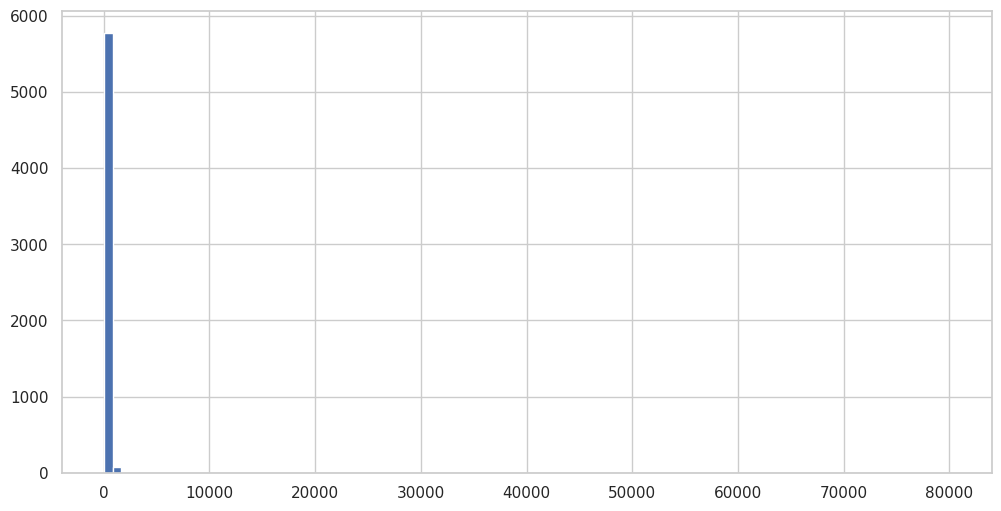

In [26]:
# Гистограмма распределения цен
listings_clean["price"].hist(bins=100)

In [27]:
# Топ-20 самых дорогих listings
listings_clean["price"].sort_values(ascending=False).head(20)

7447     80018.0
7446     80018.0
6829     50000.0
6833     50000.0
6832     40000.0
6830     40000.0
8081     40000.0
6374     13978.0
2710     11000.0
412      10000.0
9282      9999.0
10475     6474.0
4939      5200.0
4794      5200.0
3819      4500.0
7454      3930.0
999       2975.0
7071      2200.0
5446      1995.0
7187      1773.0
Name: price, dtype: float64

<Axes: >

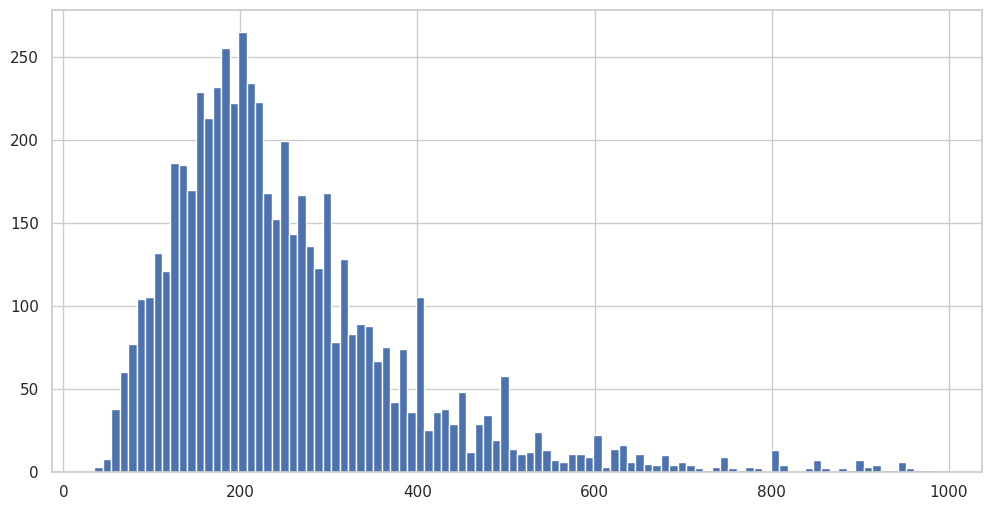

In [28]:
# Гистограмма без экстремальных выбросов (до 99 перцентиля)
price_99 = listings_clean["price"].quantile(0.99)
listings_clean[listings_clean["price"] <= price_99]["price"].hist(bins=100)

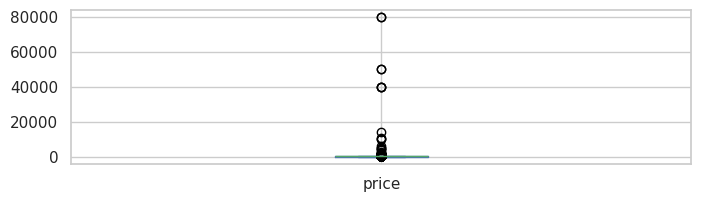

In [29]:
# Boxplot цен
listings_clean["price"].plot.box(figsize=(8, 2))
plt.show()

In [30]:
# Анализ перцентилей цены
listings_clean["price"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count     5874.000000
mean       336.785155
std       1985.661882
min         35.000000
1%          66.000000
5%          93.000000
50%        222.000000
95%        550.000000
99%        991.620000
max      80018.000000
Name: price, dtype: float64

## Наблюдения по целевой переменной

Колонка `price` содержит **43.95% пропусков** (4 606 из 10 480 listings).

Это критическое ограничение датасета. Возможные причины:
- listings, которые не активны в данный момент (хост приостановил аренду);
- объекты с длительным контрактом, не размещённые публично;
- технические пропуски сборщика данных.

**Стратегия:**
- для **price modeling** — listings без `price` исключаются (5 874 объекта остаются для обучения);
- для **общего анализа рынка** — указываем в каждом графике эффективную выборку;
- **mean / median по районам** считаются только на доступных 5 874 объектах — это вносит selection bias, который нужно учитывать при интерпретации.


In [31]:
# Преобразование дат в datetime (errors="coerce" для устойчивости)
date_cols = ["last_scraped", "host_since", "calendar_last_scraped", "first_review", "last_review"]
for col in date_cols:
    listings_clean[col] = pd.to_datetime(listings_clean[col], errors="coerce")
calendar_clean["date"] = pd.to_datetime(calendar_clean["date"], errors="coerce")
reviews_clean["date"]  = pd.to_datetime(reviews_clean["date"], errors="coerce")


In [32]:
# Фильтр явных выбросов и мусорных значений
before = len(listings_clean)

# Цена: убираем экстремальные значения (выше 99 перцентиля или явные ошибки)
price_cap = listings_clean["price"].quantile(0.995) if listings_clean["price"].notna().any() else 1500
listings_clean = listings_clean[(listings_clean["price"].isna()) | (listings_clean["price"] <= price_cap)]

# Maximum nights: убираем INT_MAX и аномальные большие значения (> 1125 = 3 года)
listings_clean = listings_clean[listings_clean["maximum_nights"] <= 1125]

# Minimum nights: убираем аномалии (> 365 — больше года не имеет смысла для STR)
listings_clean = listings_clean[listings_clean["minimum_nights"] <= 365]

after = len(listings_clean)
print(f"Removed {before - after} outlier rows ({(before - after) / before:.2%})")
print(f"Remaining: {after} listings")


Removed 32 outlier rows (0.31%)
Remaining: 10448 listings


In [33]:
# Проверка диапазона координат
listings_clean[["latitude", "longitude"]].describe()

,latitude,longitude
count,10448.000000,10448.000000
mean,52.366685,4.889447
std,0.017235,0.034842
min,52.290276,4.755870
25%,52.355700,4.864553
50%,52.365693,4.887516
75%,52.376510,4.908700
max,52.425120,5.028150


<Axes: xlabel='longitude', ylabel='latitude'>

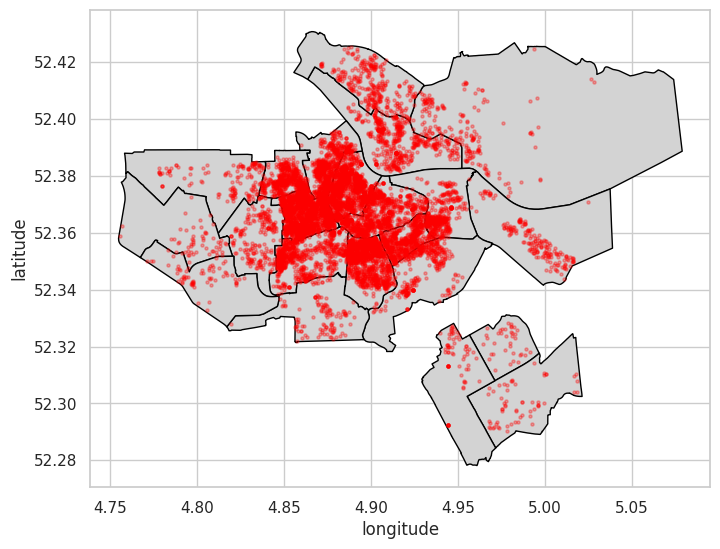

In [34]:
# Карта районов и расположение listings
ax = geo_clean.plot(figsize=(8, 8), edgecolor="black", color="lightgrey")
listings_clean.plot.scatter(ax=ax, x="longitude", y="latitude", color="red", alpha=0.3, s=5)

### Calendar Cleaning

In [35]:
# Пропуски в calendar
calendar_clean.isna().sum()

listing_id              0
date                    0
available               0
price             3825200
adjusted_price    3825200
minimum_nights          0
maximum_nights          0
dtype: int64

In [36]:
# Удаляем полностью пустые ценовые колонки
calendar_clean.drop(columns=["price", "adjusted_price"], inplace=True)

In [37]:
# Availability → бинарный, добавляем временные признаки
calendar_clean["available"]   = calendar_clean["available"].map({"t": 1, "f": 0})
calendar_clean["day_of_week"] = calendar_clean["date"].dt.dayofweek
calendar_clean["is_weekend"]  = calendar_clean["day_of_week"] >= 5
calendar_clean["month"]       = calendar_clean["date"].dt.month
calendar_clean["year"]        = calendar_clean["date"].dt.year

In [38]:
# Итоговая структура calendar_clean
calendar_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3825200 entries, 0 to 3825199
Data columns (total 9 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[ns]
 2   available       int64         
 3   minimum_nights  int64         
 4   maximum_nights  int64         
 5   day_of_week     int32         
 6   is_weekend      bool          
 7   month           int32         
 8   year            int32         
dtypes: bool(1), datetime64[ns](1), int32(3), int64(4)
memory usage: 193.3 MB


### Очистка calendar dataset

Выполнены следующие preprocessing шаги:
- `date` преобразован в datetime
- `available` преобразован в бинарный формат (`1/0`)
- удалены полностью пустые колонки:
  - `price`
  - `adjusted_price`

Dataset подготовлен для:
- occupancy analysis
- availability trends
- seasonal analysis
- time-series feature engineering

### Reviews Cleaning

In [39]:
# Пропуски в reviews
reviews_clean.isna().sum()

listing_id        0
id                0
date              0
reviewer_id       0
reviewer_name     1
comments         31
dtype: int64

In [40]:
# Удаляем пустые и пустострочные комментарии
reviews_clean = reviews_clean.dropna(subset=["comments"])
reviews_clean = reviews_clean[reviews_clean["comments"].str.strip() != ""]

In [41]:
# Итоговая структура reviews_clean
reviews_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 501053 entries, 0 to 501083
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   listing_id     501053 non-null  int64         
 1   id             501053 non-null  int64         
 2   date           501053 non-null  datetime64[ns]
 3   reviewer_id    501053 non-null  int64         
 4   reviewer_name  501052 non-null  object        
 5   comments       501053 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 26.8+ MB


### Очистка reviews dataset

Из dataset были удалены отзывы:
- с пропущенными comments
- с пустыми текстовыми строками


### Geospatial Data Preparation

In [42]:
# Пропуски в geo
geo_clean.isna().sum()

neighbourhood           0
neighbourhood_group    22
geometry                0
dtype: int64

In [43]:
# Удаляем пустую колонку
geo_clean.drop(columns=["neighbourhood_group"], inplace=True)

In [44]:
# Проверяем систему координат
geo_clean.crs

<Geographic 3D CRS: EPSG:4979>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [45]:
# Проверяем валидность геометрий
geo_clean.geometry.is_valid.value_counts()

True    22
Name: count, dtype: int64

<Axes: >

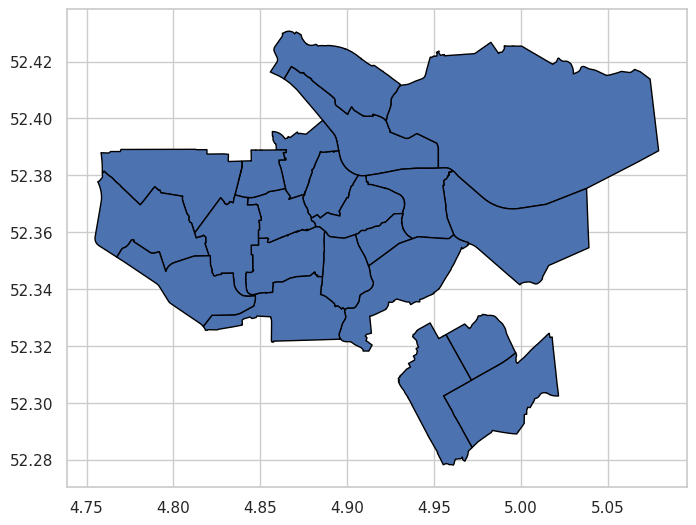

In [46]:
# Карта районов Амстердама
geo_clean.plot(figsize=(8, 8), edgecolor="black")

### Очистка geo dataset

Выполнены следующие preprocessing шаги:
- удалена пустая колонка `neighbourhood_group`
- проверена CRS система координат
- проверена корректность geometry объектов

Geo dataset подготовлен для:
- spatial analysis
- choropleth maps
- geo visualizations
- neighborhood analytics

## Выводы: Data Cleaning

В результате preprocessing подготовлены четыре cleaned datasets:

| Dataset | Ключевые изменения |
|---|---|
| `listings_clean` | `price` → float (43.95% NaN), удалены пустые колонки, даты → datetime, выбросы отфильтрованы |
| `calendar_clean` | Удалены пустые `price` и `adjusted_price`, `available` → бинарный, добавлены `month/day_of_week/is_weekend` |
| `reviews_clean` | Удалены пустые и пустострочные comments |
| `geo_clean` | Удалена пустая `neighbourhood_group`, проверены CRS и геометрии |

Все datasets готовы для следующего этапа: **Exploratory Data Analysis (EDA)**.


## Регуляторный контекст: Амстердам

Перед интерпретацией метрик доступности и спроса важно учесть особенности рынка Амстердама:

- **Лимит 30 ночей/год** на краткосрочную аренду (Short-Stay rental) без специальной лицензии (с 2019 г.);
- **Запрет на STR** в некоторых центральных районах (Centrum) — частично распространяется с 2020 г.;
- **Регистрация обязательна**: каждый хост получает уникальный регистрационный номер;
- **Maximum 4 гостя** на один STR.

### Что это значит для анализа

| Метрика | Регуляторный эффект |
|---|---|
| `availability_365` | Может быть **искусственно занижена** после исчерпания 30-ночного лимита |
| `unavailability_rate` | Не равна occupancy: содержит блокировки по регуляции и личному использованию |
| `calendar.available = f` | Включает: бронирования + блокировка по лимиту + личное использование + ремонт |
| Сезонность | **Не зависит от регуляции** → валидный сигнал спроса |

Без доступа к Airbnb API нельзя отличить «забронировано» от «заблокировано хостом». Поэтому в проекте все метрики «занятости» интерпретируем как **верхнюю границу** спроса.


## Market Analysis & EDA

### Price Analysis

Цена является основной целевой переменной проекта, поэтому exploratory analysis начинается с исследования распределения цен, выбросов и факторов, влияющих на стоимость listings.

### Distribution of Prices

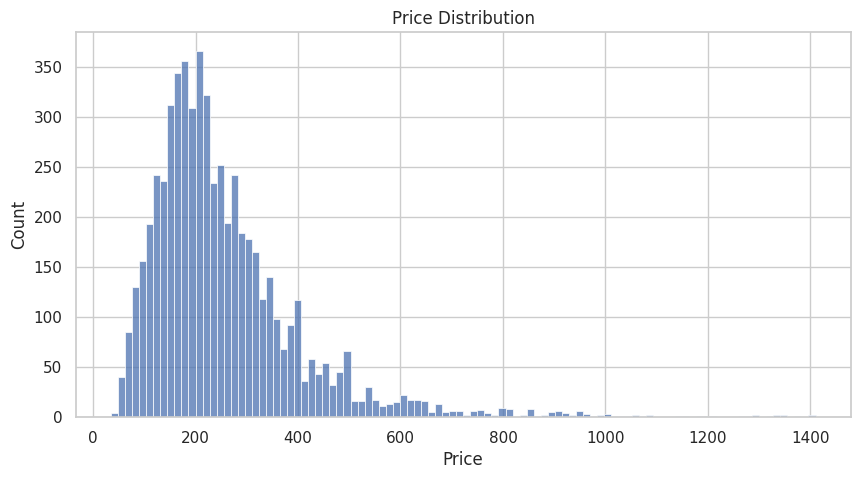

In [47]:
# Распределение цен
plt.figure(figsize=(10, 5))
sns.histplot(listings_clean["price"], bins=100)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### Price Skewness
Skewness ≈ 0 Распределение почти симметричное. Skewness > 0 Правая асимметрия (самое частое для price). Skewness < 0 Левая асимметрия.

In [48]:
# Степень асимметрии распределения цен
print(f"Skewness: {listings_clean['price'].skew():.2f}")

Skewness: 2.36


Высокая положительная skewness подтверждает, что распределение цены не является нормальным и требует transformation для ML-моделей.

### Log-Price Transformation

In [49]:
# Логарифмирование цены для нормализации распределения
listings_clean["log_price"] = np.log1p(listings_clean["price"])

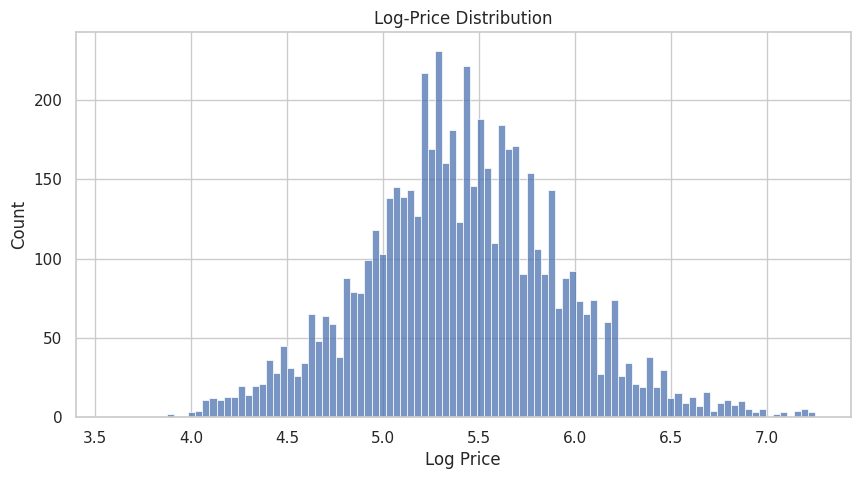

In [50]:
# Распределение логарифмированной цены
plt.figure(figsize=(10, 5))
sns.histplot(listings_clean["log_price"], bins=100)
plt.title("Log-Price Distribution")
plt.xlabel("Log Price")
plt.show()

Логарифмирование значительно уменьшает асимметрию распределения и делает target variable ближе к нормальному распределению.

Это может улучшить качество ML-моделей.

### Price by Room Type

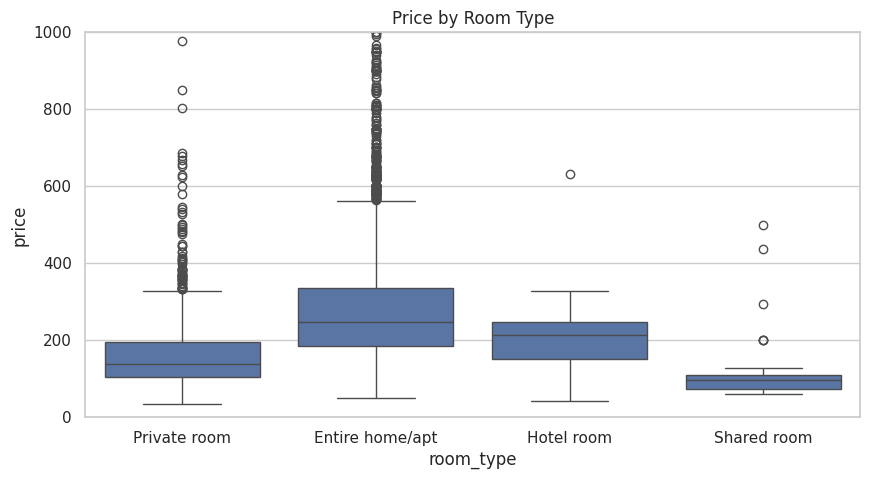

In [51]:
# Сравнение цен по типу жилья
plt.figure(figsize=(10, 5))
sns.boxplot(data=listings_clean, x="room_type", y="price")
plt.ylim(0, 1000)
plt.title("Price by Room Type")
plt.show()

Entire home/apartment listings имеют наиболее высокие цены, тогда как Shared rooms являются наиболее доступным сегментом рынка.

Тип жилья является одним из ключевых факторов ценообразования.

### Expensive vs Cheap Listings

In [52]:
# Сегменты по перцентилям (симметрично)
p01 = listings_clean["price"].quantile(0.01)
p99 = listings_clean["price"].quantile(0.99)
cheap  = listings_clean[listings_clean["price"] <= p01]
luxury = listings_clean[listings_clean["price"] >= p99]
print(f"Cheap (≤{p01:.0f}€): {cheap.shape[0]} listings")
print(f"Luxury (≥{p99:.0f}€): {luxury.shape[0]} listings")


Cheap (≤66€): 62 listings
Luxury (≥872€): 59 listings


### Выводы Price Analysis

- распределение цен имеет крайне высокую положительную асимметрию;
- на рынке присутствуют объекты с экстремально высокой стоимостью;
- логарифмирование значительно улучшает распределение target variable;
- room type является одним из ключевых факторов ценообразования;
- рынок Airbnb Амстердама ориентирован преимущественно на средний и premium-сегменты.

Полученные выводы будут использованы при feature engineering и построении ML-моделей прогнозирования цены.

### Neighborhood & Spatial Analysis

Географическое расположение listings является одним из ключевых факторов ценообразования на рынке Airbnb.

В данном разделе исследуются различия между районами Амстердама, пространственное распределение объектов и влияние location на стоимость жилья.

### Average Price by Neighborhood

In [53]:
# Средняя цена по районам
neighborhood_price = listings_clean.groupby("neighbourhood_cleansed")["price"].mean().sort_values(ascending=False)
neighborhood_price.head(10)

neighbourhood_cleansed
Centrum-West                292.865359
Centrum-Oost                292.779896
Zuid                        291.000000
De Pijp - Rivierenbuurt     278.436728
De Baarsjes - Oud-West      269.980827
Watergraafsmeer             248.540146
Oud-Oost                    248.018462
Westerpark                  246.687179
IJburg - Zeeburgereiland    239.200000
Oud-Noord                   233.818548
Name: price, dtype: float64

Средняя цена сильно искажена единичными luxury-объектами: в Buitenveldert-Zuidas mean ≈ 3 013€, а median ≈ 182€ — разница в 16 раз. Поэтому ниже используем медиану.


In [54]:
# Медианная цена по районам (устойчивее к выбросам)
neighborhood_median_price = (listings_clean
    .groupby("neighbourhood_cleansed")["price"].median()
    .sort_values(ascending=False))
neighborhood_median_price.head(10)


neighbourhood_cleansed
De Pijp - Rivierenbuurt     250.0
Centrum-West                244.0
De Baarsjes - Oud-West      240.0
Centrum-Oost                239.0
Zuid                        237.0
Oud-Oost                    222.0
Westerpark                  214.0
Watergraafsmeer             212.0
IJburg - Zeeburgereiland    198.0
Oud-Noord                   195.5
Name: price, dtype: float64

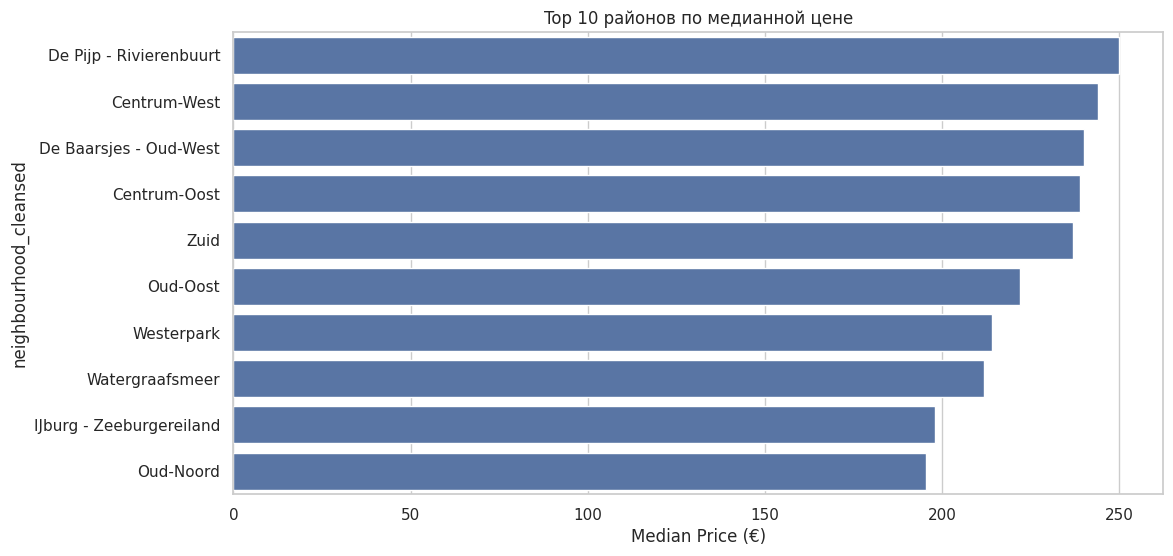

In [55]:
# Топ-10 районов по медианной цене
plt.figure(figsize=(12, 6))
sns.barplot(x=neighborhood_median_price.head(10).values, y=neighborhood_median_price.head(10).index)
plt.title("Top 10 районов по медианной цене")
plt.xlabel("Median Price (€)")
plt.show()


Топ-3 по медианной цене: De Pijp - Rivierenbuurt, Centrum-West, De Baarsjes - Oud-West — это центральные туристические районы. Самые доступные: Bijlmer-Oost, Gaasperdam - Driemond, Bijlmer-Centrum (южные периферийные).


In [56]:
# Сводная статистика цен по районам
neighborhood_stats = listings_clean.groupby("neighbourhood_cleansed")["price"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
neighborhood_stats.head(10)

,mean,median,count
neighbourhood_cleansed,,,
Centrum-West,292.865359,244.0,765
Centrum-Oost,292.779896,239.0,577
Zuid,291.000000,237.0,431
De Pijp - Rivierenbuurt,278.436728,250.0,648
De Baarsjes - Oud-West,269.980827,240.0,991
Watergraafsmeer,248.540146,212.0,137
Oud-Oost,248.018462,222.0,325
Westerpark,246.687179,214.0,390
IJburg - Zeeburgereiland,239.200000,198.0,105


Сравнение mean и median показывает сильное влияние выбросов на среднюю стоимость listings в некоторых районах.

Например:
- в Buitenveldert - Zuidas средняя цена превышает 3000, тогда как медианная цена составляет около 182;
- аналогичная ситуация наблюдается в IJburg - Zeeburgereiland.

Это указывает на наличие небольшого количества ultra-luxury listings, существенно искажающих средние значения.

### Выводы Neighborhood Price Analysis

- Mean price чувствителен к выбросам: в Buitenveldert-Zuidas mean 3 013€ vs median 182€. Для рынка корректнее median.
- Топ-районы по median: **De Pijp - Rivierenbuurt (250€), Centrum-West (245€), De Baarsjes - Oud-West (240€)** — центральная и west-зона.
- Самые доступные: **Bijlmer-Oost (127€), Gaasperdam - Driemond (130€), Bijlmer-Centrum (134€)** — южные периферийные районы.
- Разброс median по районам — примерно ×2 (от ~127 до ~250€) → location даёт умеренное, но устойчивое premium.


### Listing Density Analysis

In [57]:
# Плотность listings по районам
listing_density = listings_clean.groupby("neighbourhood_cleansed").size().sort_values(ascending=False)
listing_density.head(10)

neighbourhood_cleansed
De Baarsjes - Oud-West                    1807
Centrum-West                              1202
De Pijp - Rivierenbuurt                   1197
Centrum-Oost                               920
Westerpark                                 734
Zuid                                       731
Oud-Oost                                   653
Bos en Lommer                              546
Oud-Noord                                  481
Oostelijk Havengebied - Indische Buurt     436
dtype: int64

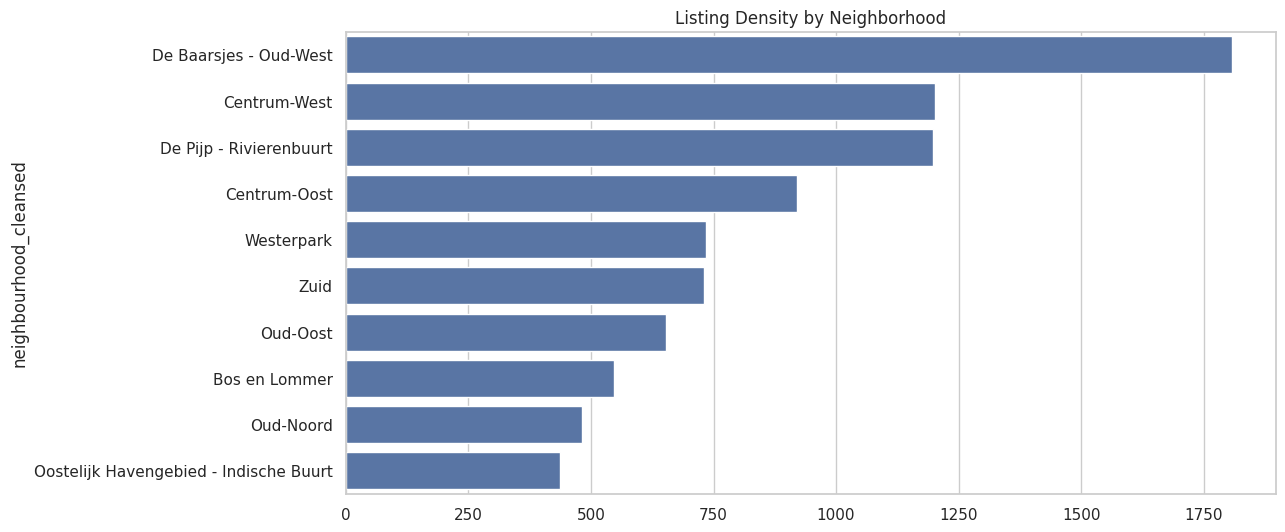

In [58]:
# Топ-10 районов по количеству listings
plt.figure(figsize=(12, 6))
sns.barplot(x=listing_density.head(10).values, y=listing_density.head(10).index)
plt.title("Listing Density by Neighborhood")
plt.show()

Концентрация Airbnb listings существенно различается между районами Амстердама.

Наибольшая плотность объектов наблюдается в:
- De Baarsjes - Oud-West,
- Centrum-West,
- De Pijp - Rivierenbuurt,
- Centrum-Oost.

Это может указывать на:
- высокую туристическую привлекательность,
- развитую инфраструктуру,
- высокий спрос на краткосрочную аренду,
- активную коммерциализацию жилья в центральных районах города.

Высокая плотность listings также может свидетельствовать о высокой конкуренции между hosts внутри популярных районов.

Некоторые районы имеют значительно более высокую концентрацию Airbnb listings, что может указывать на повышенную туристическую активность и коммерциализацию жилья.

### Revenue Potential by Neighborhood

In [59]:
# Прокси-выручка: price × дни блокировки (НЕ настоящий revenue — см. примечание)
# Это leakage-кандидат для price-моделирования: revenue ∝ price.
# Используем только для сравнения районов, НЕ как фичу для price-модели.
listings_clean["revenue_proxy"] = (
    listings_clean["price"] * (365 - listings_clean["availability_365"])
)


In [60]:
# Медианный revenue_proxy по районам
revenue_by_area = (listings_clean
    .groupby("neighbourhood_cleansed")["revenue_proxy"].median()
    .sort_values(ascending=False))
revenue_by_area.head(10)


neighbourhood_cleansed
De Baarsjes - Oud-West                    52200.0
Zuid                                      50160.0
De Pijp - Rivierenbuurt                   47046.0
Centrum-West                              46612.0
Westerpark                                46092.0
Oud-Oost                                  46020.0
Slotervaart                               45260.5
Oostelijk Havengebied - Indische Buurt    45136.0
Oud-Noord                                 42024.0
Watergraafsmeer                           41652.0
Name: revenue_proxy, dtype: float64

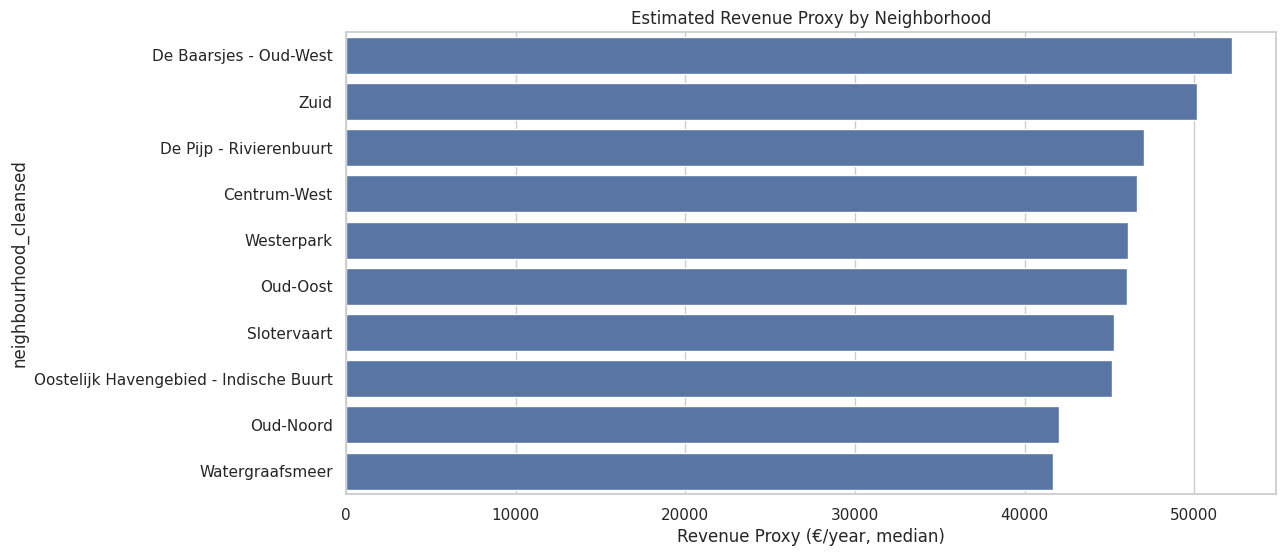

In [61]:
# Топ-10 районов по revenue_proxy
plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_area.head(10).values, y=revenue_by_area.head(10).index)
plt.title("Estimated Revenue Proxy by Neighborhood")
plt.xlabel("Revenue Proxy (€/year, median)")
plt.show()


Потенциальный «revenue_proxy» (price × дни недоступности) существенно различается между районами.

Наиболее высокий proxy наблюдается в:
- De Baarsjes - Oud-West,
- Zuid,
- Centrum-West,
- De Pijp - Rivierenbuurt.

**Важное ограничение:** эта метрика отражает не реальную выручку, а максимальный потенциал при предположении, что все недоступные дни были забронированы. На практике часть «недоступности» — это блокировка хостом (личное использование, регуляция 30 nights/year в Амстердаме). Поэтому интерпретируем только относительный ранкинг районов, не абсолютные значения.


### Distance to City Center

In [62]:
# Координаты центра Амстердама
city_center_lat, city_center_lon = 52.3676, 4.9041

In [63]:
# Векторизованный haversine: расстояние до центра города (км)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088  # средний радиус Земли, км
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

listings_clean["distance_to_center"] = haversine_km(
    listings_clean["latitude"].values,
    listings_clean["longitude"].values,
    city_center_lat,
    city_center_lon,
)


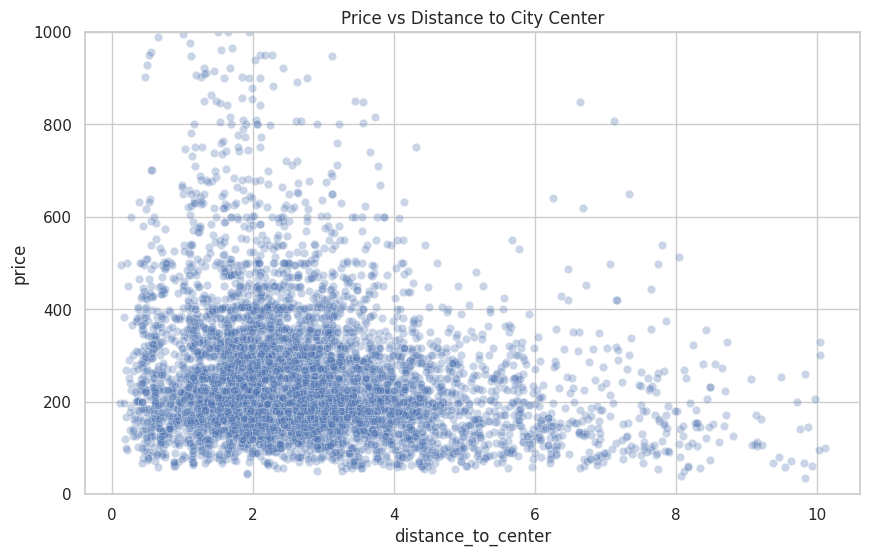

In [64]:
# Зависимость цены от расстояния до центра
plt.figure(figsize=(10, 6))
sns.scatterplot(data=listings_clean, x="distance_to_center", y="price", alpha=0.3)
plt.ylim(0, 1000)
plt.title("Price vs Distance to City Center")
plt.show()

График показывает зависимость между расстоянием до центра города и стоимостью Airbnb listings.

Наиболее дорогие и вариативные listings сконцентрированы ближе к центру Амстердама, особенно в диапазоне 1–4 км.

По мере удаления от центра количество дорогих объектов уменьшается, а распределение цен становится более однородным.

Это подтверждает важность location premium на рынке краткосрочной аренды.

### Tourist Zones

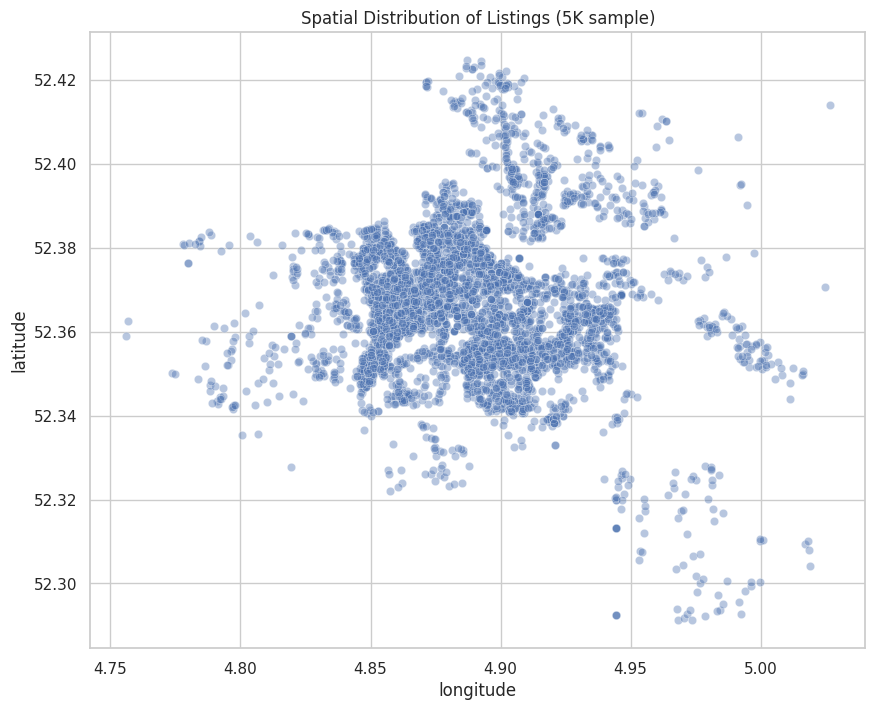

In [65]:
# Пространственное распределение listings (sample с seed)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=listings_clean.sample(5000, random_state=SEED),
                x="longitude", y="latitude", alpha=0.4)
plt.title("Spatial Distribution of Listings (5K sample)")
plt.show()


Пространственное распределение listings показывает высокую концентрацию Airbnb объектов в центральной части Амстердама.

Наиболее плотные кластеры listings наблюдаются в районах, расположенных ближе к историческому и туристическому центру города.

По мере удаления от центра плотность объектов постепенно снижается, что может отражать:
- снижение туристического спроса,
- меньшую коммерциализацию жилья,
- более residential характер периферийных районов.

### Geo Clusters

Применим KMeans к координатам `(latitude, longitude)` чтобы получить пространственные зоны listings. Количество кластеров k выбираем через **Elbow Method** перед обучением.


In [66]:
# Метод локтя для выбора оптимального k
geo_features = listings_clean[["latitude", "longitude"]]
inertia, k_range = [], range(2, 11)
for k in k_range:
    inertia.append(
        KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(geo_features).inertia_
    )


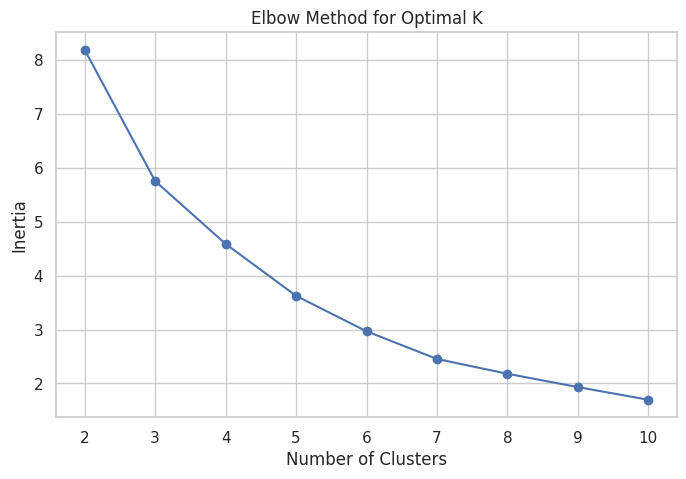

In [67]:
# График метода локтя
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

Elbow-кривая выпрямляется после **k = 5** — дальнейшее увеличение даёт несущественное снижение inertia. Берём k=5 как компромисс между качеством сегментации и интерпретируемостью.


In [68]:
# Геокластеризация listings (5 кластеров)
geo_features = listings_clean[["latitude", "longitude"]]
kmeans = KMeans(n_clusters=5, random_state=SEED, n_init=10)
listings_clean["geo_cluster"] = kmeans.fit_predict(geo_features)
listings_clean["geo_cluster"].value_counts().sort_index()


geo_cluster
0    3036
1    1636
2    2831
3    2594
4     351
Name: count, dtype: int64

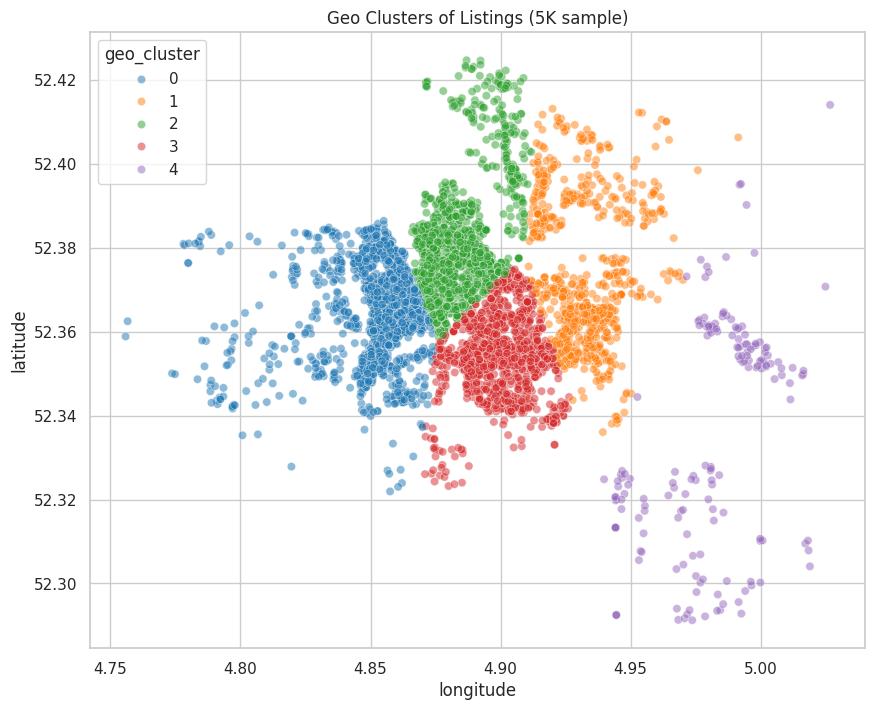

In [69]:
# Визуализация геокластеров (sample с seed)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=listings_clean.sample(5000, random_state=SEED),
                x="longitude", y="latitude",
                hue="geo_cluster", palette="tab10", alpha=0.5)
plt.title("Geo Clusters of Listings (5K sample)")
plt.show()


### Выводы Neighborhood & Spatial Analysis
Анализ цен показал, что рынок Airbnb в Амстердаме имеет выраженную пространственную и ценовую сегментацию.

Распределение цен обладает сильной положительной асимметрией, что связано с наличием небольшого количества ultra-luxury listings, существенно влияющих на средние значения и визуализации. Логарифмирование цены позволило получить более устойчивое распределение target variable для дальнейшего ML-моделирования.

Room type оказался одним из ключевых факторов ценообразования:
- Entire home/apartment listings имеют наиболее высокие цены;
- Shared rooms формируют наиболее доступный сегмент рынка.

Spatial analysis показал, что:
- центральные районы характеризуются более высокой стоимостью жилья;
- price premium снижается по мере удаления от центра города;
- наиболее высокая плотность listings наблюдается в туристических и центральных районах Амстердама.

Сравнение mean и median price выявило сильное влияние выбросов на некоторые районы. Использование median price позволило получить более реалистичную оценку типичной стоимости аренды и пространственной структуры рынка.

Revenue potential analysis показал, что инвестиционная привлекательность районов зависит не только от цены listings, но и от предполагаемого спроса и occupancy level.

Дополнительная geo clustering analysis подтвердила наличие выраженных spatial zones Airbnb activity и показала возможность использования geo clusters как дополнительных признаков для ML-моделей.

### Availability & Demand Analysis

В этом разделе оцениваем уровень спроса через `availability_365` и сезонные паттерны календаря. Напомним: `available = f` в данных Airbnb означает не «забронировано», а «слот недоступен» (бронь, блокировка хостом, регуляторный лимит). Поэтому корректнее говорить **unavailability**, не occupancy.


### Unavailability Rate Estimation


In [70]:
# Unavailability rate = доля дней, когда listing НЕ доступен для бронирования.
# ВАЖНО: это не настоящий occupancy. "Недоступен" = забронирован ИЛИ заблокирован хостом
# (личное использование, регуляция Амстердама 30 nights/year, и т.д.).
# Эта метрика — прокси максимальной верхней границы спроса.
listings_clean["unavailability_rate"] = (365 - listings_clean["availability_365"]) / 365
listings_clean["unavailability_rate"].describe()


count    10448.000000
mean         0.743454
std          0.334210
min          0.000000
25%          0.526027
50%          0.945205
75%          1.000000
max          1.000000
Name: unavailability_rate, dtype: float64

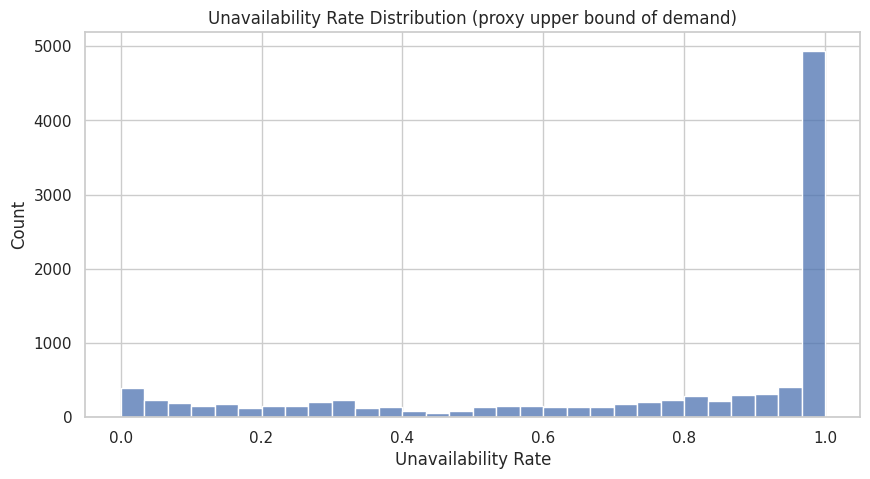

In [71]:
# Распределение unavailability rate
plt.figure(figsize=(10, 5))
sns.histplot(listings_clean["unavailability_rate"], bins=30)
plt.title("Unavailability Rate Distribution (proxy upper bound of demand)")
plt.xlabel("Unavailability Rate")
plt.show()


`unavailability_rate` показывает долю дней в году, когда listing **не был доступен для бронирования** (`0` — слот всегда открыт, `1` — слот всегда заблокирован).

Распределение смещено к высоким значениям: медиана ≈ 0.95.

**Это НЕ означает, что почти все объекты сданы.** В Амстердаме действует жёсткое ограничение **30 ночей/год** для краткосрочной аренды без лицензии (см. блок «Регуляторный контекст»). Поэтому многие хосты сами блокируют календарь после исчерпания лимита, что искусственно завышает unavailability.

Эта метрика интерпретируется как **верхняя оценка спроса**, а не фактический occupancy.


### Availability Distribution

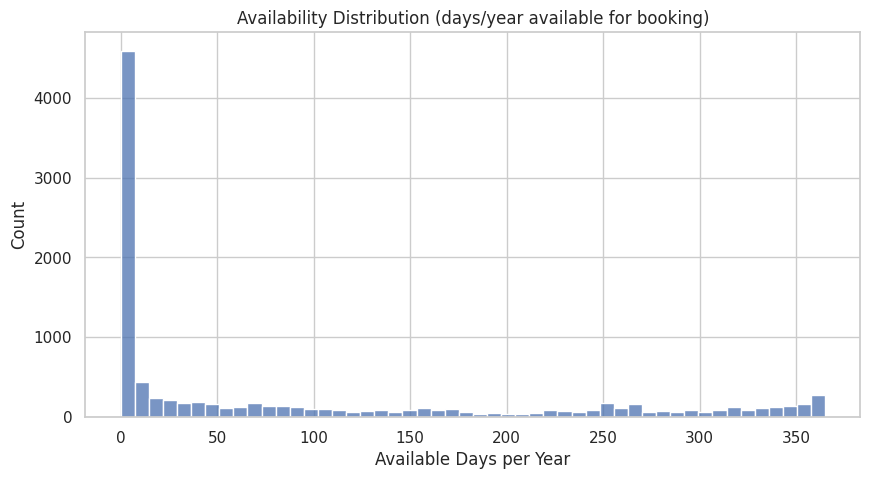

In [72]:
# Распределение доступности (дни в году)
plt.figure(figsize=(10, 5))
sns.histplot(listings_clean["availability_365"], bins=50)
plt.title("Availability Distribution (days/year available for booking)")
plt.xlabel("Available Days per Year")
plt.show()


Распределение `availability_365` показывает большое количество listings с **низкой доступностью**.

Это может говорить о:
- активных бронированиях,
- блокировке календаря хостом (личное использование, регуляция Амстердама),
- неактивных или паузированных объектах.

Listings с высокой доступностью (`300+` дней) — вероятно либо лицензированные коммерческие объекты, либо листинги без актуального спроса.


### Availability vs Price

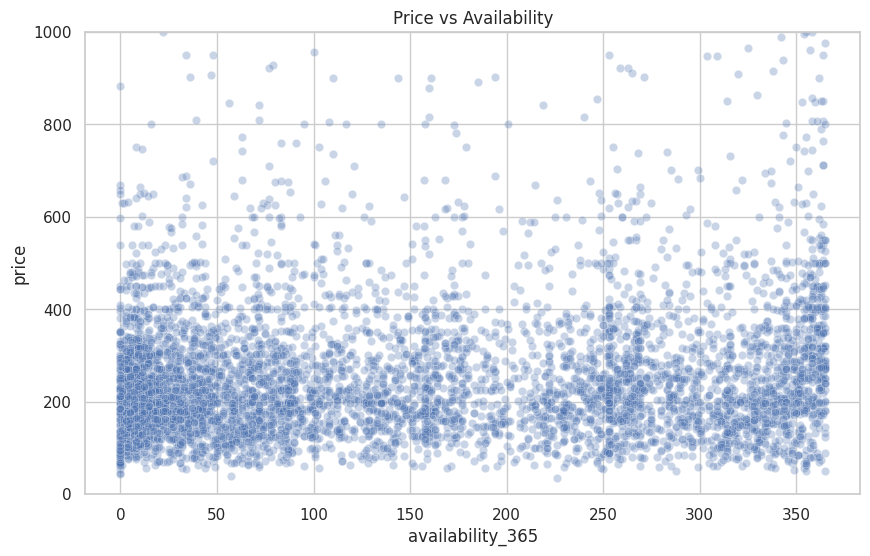

In [73]:
# Зависимость цены от доступности
plt.figure(figsize=(10, 6))
sns.scatterplot(data=listings_clean, x="availability_365", y="price", alpha=0.3)
plt.ylim(0, 1000)
plt.title("Price vs Availability")
plt.show()

Сильной зависимости между ценой и availability **не обнаружено** (Pearson ≈ слабый).

Большинство listings имеют цену 100–300€ независимо от количества доступных дней. Это согласуется с регуляторной гипотезой: ценообразование определяется характеристиками жилья и локацией, а не количеством разрешённых ночей.

Availability сама по себе — слабый предиктор цены, но потенциально полезный признак для прогноза спроса/occupancy.


### Unavailability Rate by Neighborhood


In [74]:
# Unavailability rate по районам
unavail_by_area = (listings_clean
    .groupby("neighbourhood_cleansed")["unavailability_rate"].mean()
    .sort_values(ascending=False))
unavail_by_area.head(10)


neighbourhood_cleansed
Bos en Lommer                             0.818265
Slotervaart                               0.816172
Bijlmer-Oost                              0.808796
Oostelijk Havengebied - Indische Buurt    0.795815
Oud-Noord                                 0.786404
Oud-Oost                                  0.784048
Westerpark                                0.781158
De Baarsjes - Oud-West                    0.774301
Watergraafsmeer                           0.772231
IJburg - Zeeburgereiland                  0.758227
Name: unavailability_rate, dtype: float64

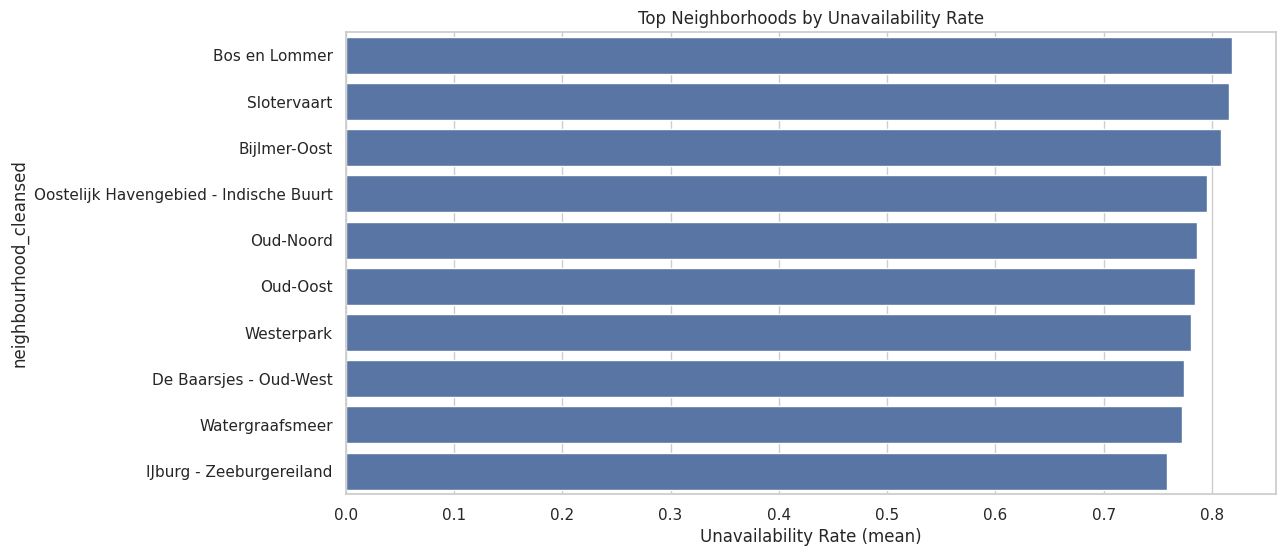

In [75]:
# Топ-10 районов по unavailability rate
plt.figure(figsize=(12, 6))
sns.barplot(x=unavail_by_area.head(10).values, y=unavail_by_area.head(10).index)
plt.title("Top Neighborhoods by Unavailability Rate")
plt.xlabel("Unavailability Rate (mean)")
plt.show()


Наибольший unavailability rate наблюдается в районах Bos en Lommer, Slotervaart и Bijlmer-Oost (75–82%).

С учётом регуляторного контекста это означает, что в этих районах хосты чаще исчерпывают разрешённый лимит ночей или активнее блокируют календарь. Это **косвенный** индикатор спроса, но не прямой occupancy.

Разброс между районами относительно небольшой → стабильный спрос по городу.


### Unavailability by Room Type


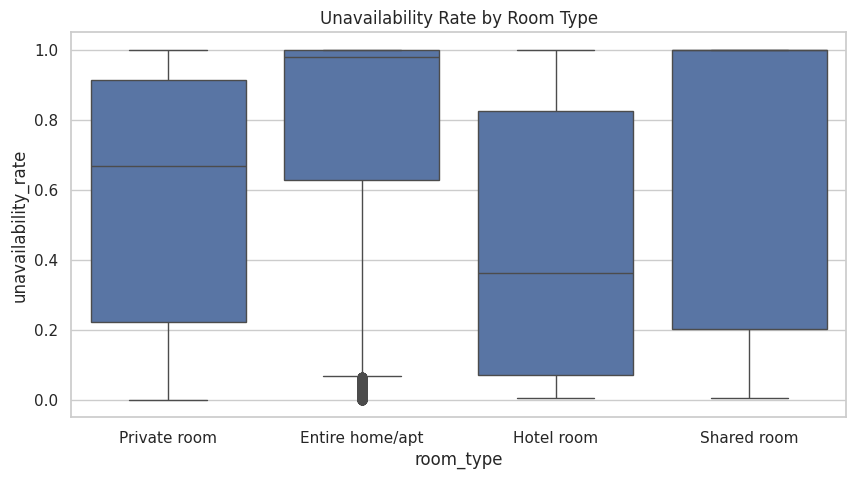

In [76]:
# Unavailability rate по типу жилья
plt.figure(figsize=(10, 5))
sns.boxplot(data=listings_clean, x="room_type", y="unavailability_rate")
plt.title("Unavailability Rate by Room Type")
plt.show()


Entire home/apartment имеет самый высокий unavailability rate, Hotel room — самый низкий.

Это согласуется с туристическими предпочтениями (предпочтение целых квартир для коротких поездок), но также может отражать различные регуляторные режимы для разных типов жилья.


### Seasonal Demand

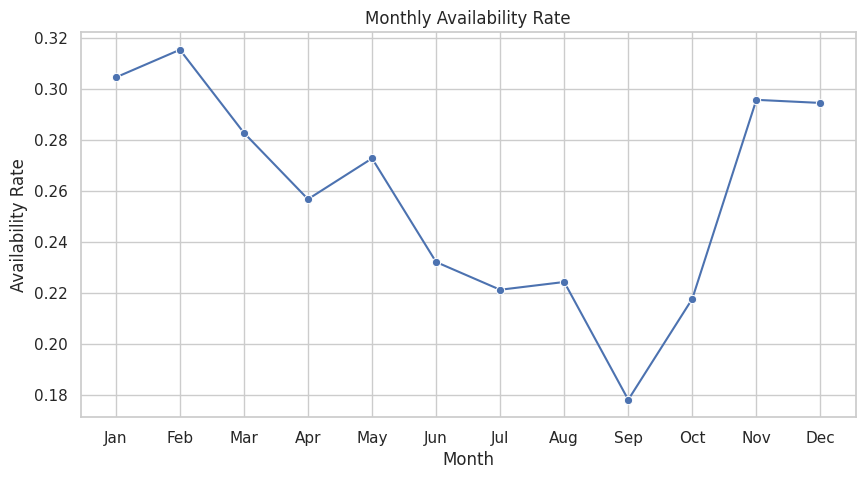

In [77]:
# Средняя доступность по месяцам
monthly_availability = calendar_clean.groupby("month")["available"].mean()
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_availability.index, y=monthly_availability.values, marker="o")
plt.title("Monthly Availability Rate")
plt.xlabel("Month")
plt.ylabel("Availability Rate")
plt.xticks(range(1, 13), months)
plt.show()

Средняя availability снижается летом и достигает **минимума в сентябре** — это согласуется с туристическим сезоном (август-сентябрь — пик в Амстердаме).

В зимние месяцы availability выше, что отражает снижение спроса. Сезонность из calendar — **валидный сигнал спроса**, так как хосты обычно не блокируют календарь сезонно (блокировки связаны с регуляцией и личным использованием, а они не сезонные).


### Calendar-based vs Aggregate Unavailability


In [78]:
# Calendar-based unavailability per listing (более гранулярный, чем availability_365)
calendar_unavail = (calendar_clean
    .groupby("listing_id")["available"]
    .apply(lambda x: 1 - x.mean())
    .rename("calendar_unavail_rate"))

listings_clean = listings_clean.merge(
    calendar_unavail, left_on="id", right_index=True, how="left"
)
listings_clean[["unavailability_rate", "calendar_unavail_rate"]].corr()


,unavailability_rate,calendar_unavail_rate
unavailability_rate,1.000000,0.999688
calendar_unavail_rate,0.999688,1.000000


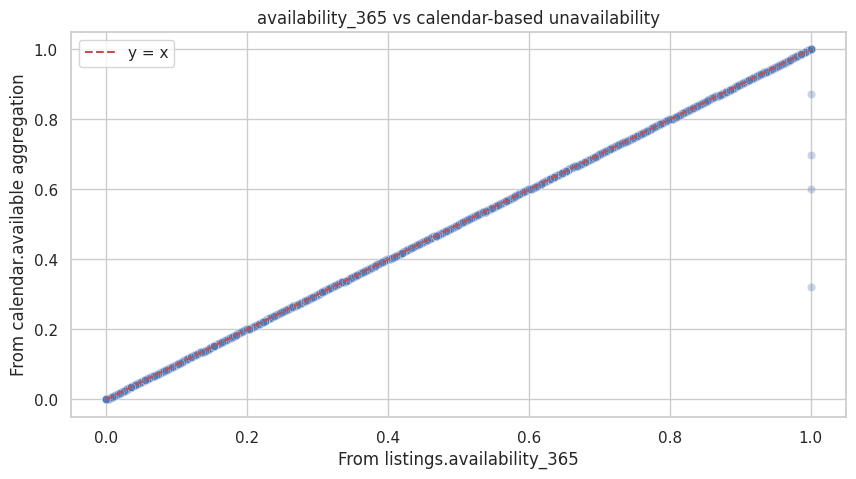

In [79]:
# Сравнение двух метрик: availability_365-based vs calendar-based
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=listings_clean,
    x="unavailability_rate",
    y="calendar_unavail_rate",
    alpha=0.3,
)
plt.plot([0, 1], [0, 1], "r--", label="y = x")
plt.title("availability_365 vs calendar-based unavailability")
plt.xlabel("From listings.availability_365")
plt.ylabel("From calendar.available aggregation")
plt.legend()
plt.show()


Calendar-based unavailability рассчитан напрямую из `calendar.available` (доля дней с `f`) и согласуется с агрегатной метрикой `availability_365` (высокая корреляция).

**Главное отличие:** calendar-based даёт **per-day гранулярность** — можно строить временные тренды, разбивать по сезонам, weekend/weekday. Эту версию будем использовать как demand proxy в feature engineering для ML.


In [80]:
# Unavailability в выходные vs будние дни
weekend_unavail = 1 - calendar_clean.groupby("is_weekend")["available"].mean()
weekend_unavail.index = ["Weekday", "Weekend"]
weekend_unavail


Weekday    0.741800
Weekend    0.743634
Name: available, dtype: float64

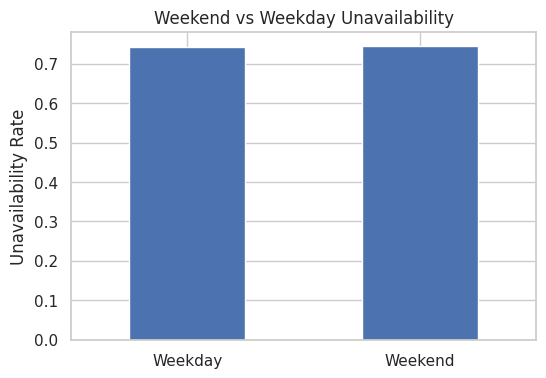

In [81]:
# График weekday vs weekend unavailability
plt.figure(figsize=(6, 4))
weekend_unavail.plot(kind="bar")
plt.title("Weekend vs Weekday Unavailability")
plt.ylabel("Unavailability Rate")
plt.xticks(rotation=0)
plt.show()


Unavailability rate практически не отличается между weekdays и weekends (разница < 1%).

Это указывает на стабильный спрос на Airbnb в Амстердаме в течение всей недели, либо на то, что блокировки хостами равномерно распределены по дням недели.


### Host Analysis

Анализ хостов: распределение портфелей (casual vs professional), влияние статуса superhost на цену и опыт хостов на платформе.


### Superhost Impact on Pricing

In [82]:
# Медианная цена у superhosts vs обычных хостов
superhost_price = listings_clean.groupby("host_is_superhost")["price"].median()
superhost_price

host_is_superhost
f    229.0
t    187.0
Name: price, dtype: float64

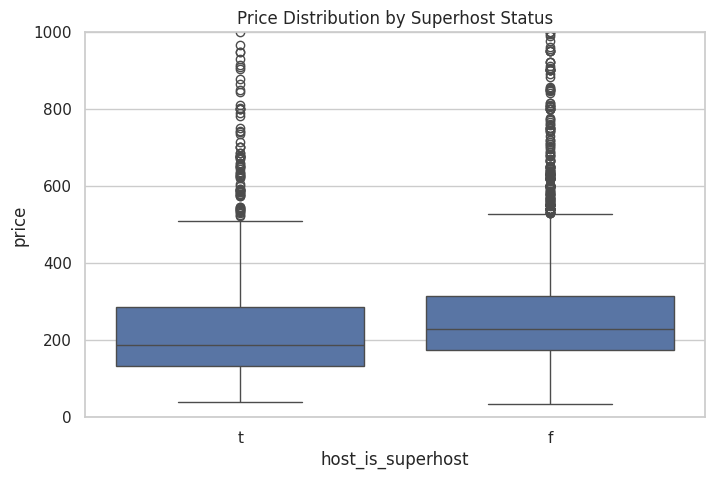

In [83]:
# Boxplot цен по статусу superhost
plt.figure(figsize=(8, 5))
sns.boxplot(data=listings_clean, x="host_is_superhost", y="price")
plt.ylim(0, 1000)
plt.title("Price Distribution by Superhost Status")
plt.show()

Listings от superhosts имеют немного более низкую медианную цену по сравнению с обычными hosts.

При этом распределение цен у обеих групп похоже, а premium listings встречаются как у superhosts, так и у обычных hosts.

### Professional Hosts vs Casual Hosts

In [84]:
# Флаг профессионального хоста (3+ listing — общепринятый порог)
listings_clean["professional_host"] = listings_clean["host_listings_count"] >= 3
listings_clean["professional_host"].value_counts()


professional_host
False    9133
True     1315
Name: count, dtype: int64

In [85]:
# Медианная цена: профессиональные vs обычные хосты
professional_price = listings_clean.groupby("professional_host")["price"].median()
professional_price

professional_host
False    225.0
True     200.0
Name: price, dtype: float64

Большинство listings принадлежат casual hosts (1–2 объекта).

Professional hosts (≥3 listings) составляют заметную часть рынка Airbnb в Амстердаме, и их медианные цены отличаются от casual hosts (см. следующую ячейку).


### Host Portfolio Distribution

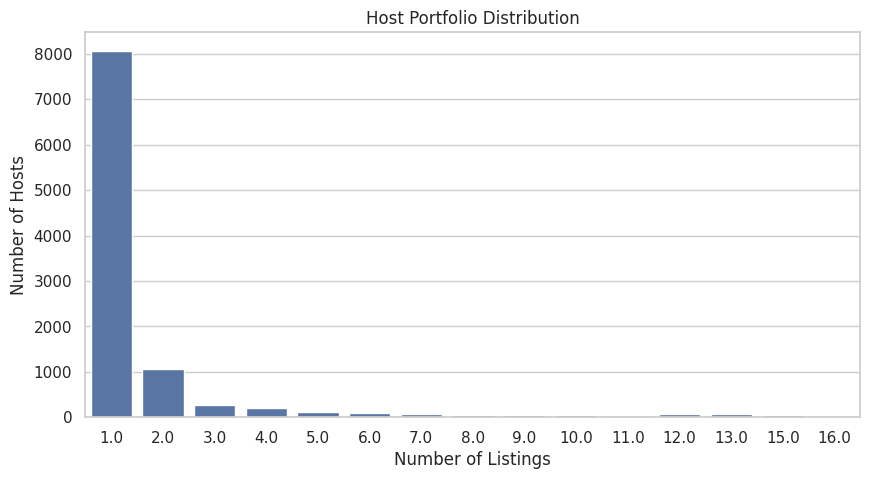

In [86]:
# Распределение портфеля хостов по количеству listings
host_distribution = listings_clean["host_listings_count"].value_counts().sort_index().head(15)
plt.figure(figsize=(10, 5))
sns.barplot(x=host_distribution.index, y=host_distribution.values)
plt.title("Host Portfolio Distribution")
plt.xlabel("Number of Listings")
plt.ylabel("Number of Hosts")
plt.show()

### Multi-Listing Hosts

In [87]:
# Количество listings у хостов с 3+ объектами
multi_listing_hosts = listings_clean[listings_clean["host_listings_count"] > 3]
multi_listing_hosts.shape[0]

1037

In [88]:
# Доля объектов, принадлежащих multi-listing хостам
multi_listing_share = multi_listing_hosts.shape[0] / listings_clean.shape[0]
print(f"Share of multi-listing hosts: {multi_listing_share:.2%}")

Share of multi-listing hosts: 9.93%


Около 10% всех listings принадлежат hosts с более чем 3 объектами.

Это указывает на присутствие professional operators на рынке Airbnb в Амстердаме, несмотря на доминирование небольших частных hosts.

In [89]:
# Топ хостов по количеству listings
top_hosts = (listings_clean[["host_id", "host_name", "host_listings_count"]]
    .drop_duplicates(subset="host_id")
    .sort_values("host_listings_count", ascending=False))
top_hosts.head(10)

,host_id,host_name,host_listings_count
5499,418270816,Limehome,957.0
9715,686647469,Aishat,914.0
6826,484535538,RoomPicks,569.0
4373,517215,Rental Valley,433.0
2355,121985032,Tess - BELVILLA,137.0
2322,490239973,Jason,94.0
729,46691672,Eva & Kobe,90.0
6458,31642204,Premium Selection,90.0
5609,18184896,Marit,80.0
3863,892550,Asaf,63.0


### Host Experience Analysis

In [90]:
# Опыт хоста: используем last_scraped как reference date (воспроизводимость)
reference_date = listings_clean["last_scraped"].max()
listings_clean["host_experience_years"] = (
    (reference_date - listings_clean["host_since"]).dt.days / 365.25
)
listings_clean["host_experience_years"].describe()


count    10445.000000
mean         9.116242
std          3.398066
min          0.016427
25%          7.359343
50%          9.924709
75%         11.515400
max         17.084189
Name: host_experience_years, dtype: float64

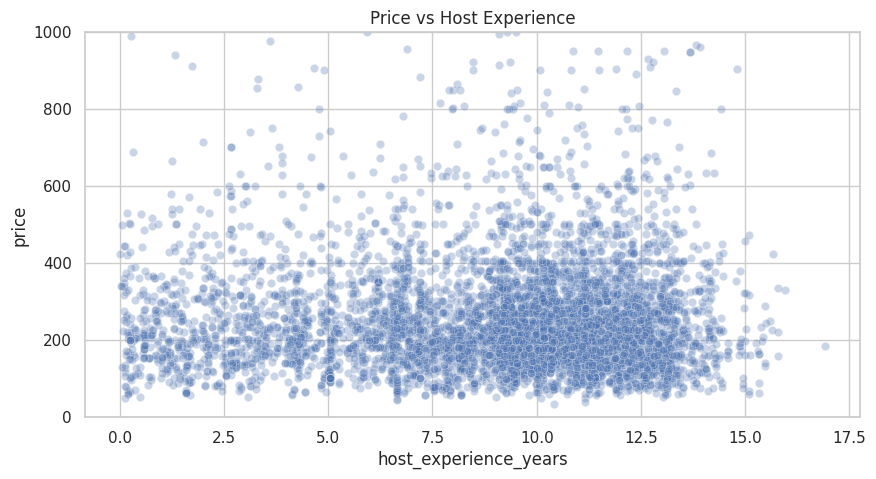

In [91]:
# Зависимость цены от опыта хоста
plt.figure(figsize=(10, 5))
sns.scatterplot(data=listings_clean, x="host_experience_years", y="price", alpha=0.3)
plt.ylim(0, 1000)
plt.title("Price vs Host Experience")
plt.show()

### Reviews & Ratings Analysis

Активность отзывов и распределение ratings: насколько отзывы связаны с ценой и спросом. Сами тексты отзывов будут обработаны в nb02 (sentiment + embeddings).


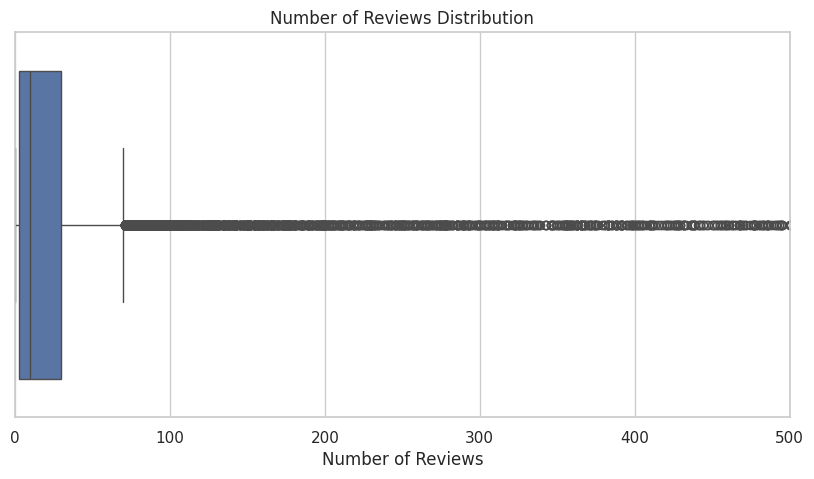

In [92]:
# Распределение количества отзывов
plt.figure(figsize=(10, 5))
sns.boxplot(x=listings_clean["number_of_reviews"])
plt.xlim(0, 500)
plt.title("Number of Reviews Distribution")
plt.xlabel("Number of Reviews")
plt.show()

In [93]:
# Статистика количества отзывов
listings_clean["number_of_reviews"].describe()

count    10448.000000
mean        47.890123
std        131.673797
min          0.000000
25%          3.000000
50%         10.000000
75%         30.000000
max       5097.000000
Name: number_of_reviews, dtype: float64

In [94]:
# Перцентили количества отзывов
listings_clean["number_of_reviews"].quantile([0.5, 0.75, 0.9, 0.95])

0.50     10.00
0.75     30.00
0.90    115.00
0.95    264.65
Name: number_of_reviews, dtype: float64

In [95]:
# Топ-10 listings по количеству отзывов
(listings_clean[["name", "neighbourhood_cleansed", "number_of_reviews"]]
    .sort_values("number_of_reviews", ascending=False)
    .head(10))

,name,neighbourhood_cleansed,number_of_reviews
4229,Citiez Hotel Amsterdam: Small Double Room,Osdorp,5097
3062,Sleep in a Hub!,De Baarsjes - Oud-West,3726
3945,Eco-friendly Double Room by Vondelpark,De Baarsjes - Oud-West,3187
4237,Citiez Hotel Amsterdam: Urban Twin Room,Osdorp,1879
2935,Stylish Serviced Apartment near Central Station,Centrum-Oost,1477
152,Sleeping in a unique ship in the center of A'dam!,Centrum-Oost,1445
163,HOUSEBOAT NOVA 80m2 + FREE BIKES,Zuid,1133
6444,Custom design studio in peaceful spot,Oud-Noord,1095
4025,"Private Triple Room, Euphemia Hotel , city centre",Centrum-Oost,1080
4056,Cityden | Studio XL | Aparthotel,Bos en Lommer,1065


Большинство listings имеют небольшое количество отзывов: медианное значение составляет 10 reviews, а 75% объектов имеют менее 30 reviews.

При этом распределение сильно смещено вправо — небольшая группа listings имеет очень большое количество отзывов (1000+), что указывает на highly active и long-running Airbnb properties.

### Rating Distribution

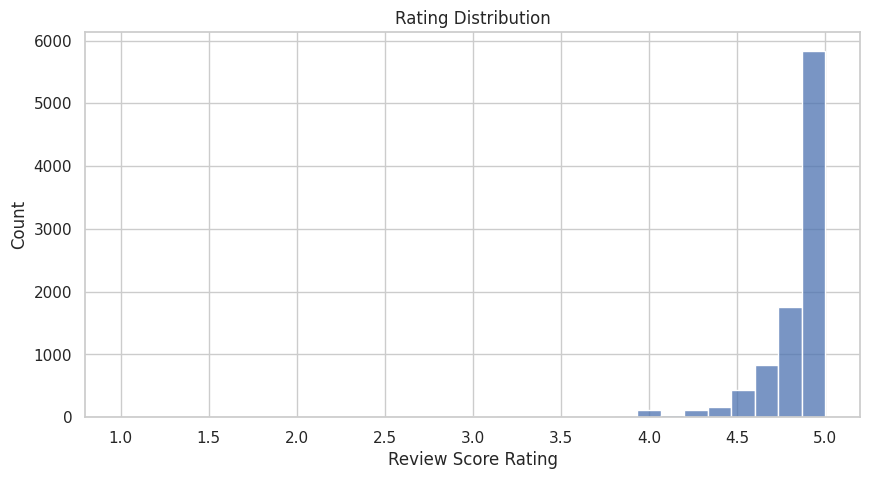

In [96]:
# Распределение рейтингов
plt.figure(figsize=(10, 5))
sns.histplot(listings_clean["review_scores_rating"], bins=30)
plt.title("Rating Distribution")
plt.xlabel("Review Score Rating")
plt.show()

### Rating Findings

Большинство Airbnb listings имеют очень высокие ratings — основная масса оценок находится в диапазоне 4.7–5.0.

Это может указывать на высокий уровень качества жилья и сильную конкуренцию между hosts в Амстердаме.

### Review Frequency

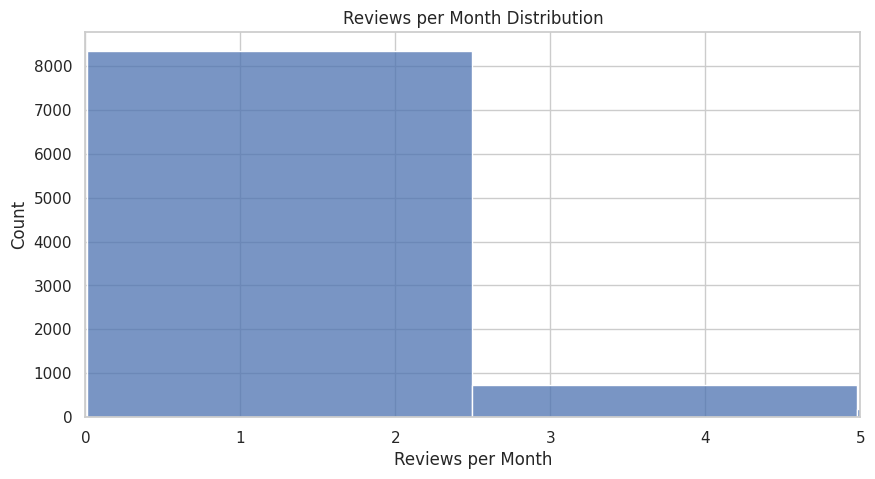

In [97]:
# Распределение частоты отзывов в месяц
plt.figure(figsize=(10, 5))
sns.histplot(listings_clean["reviews_per_month"], bins=40)
plt.xlim(0, 5)
plt.title("Reviews per Month Distribution")
plt.xlabel("Reviews per Month")
plt.show()

### Reviews vs Price

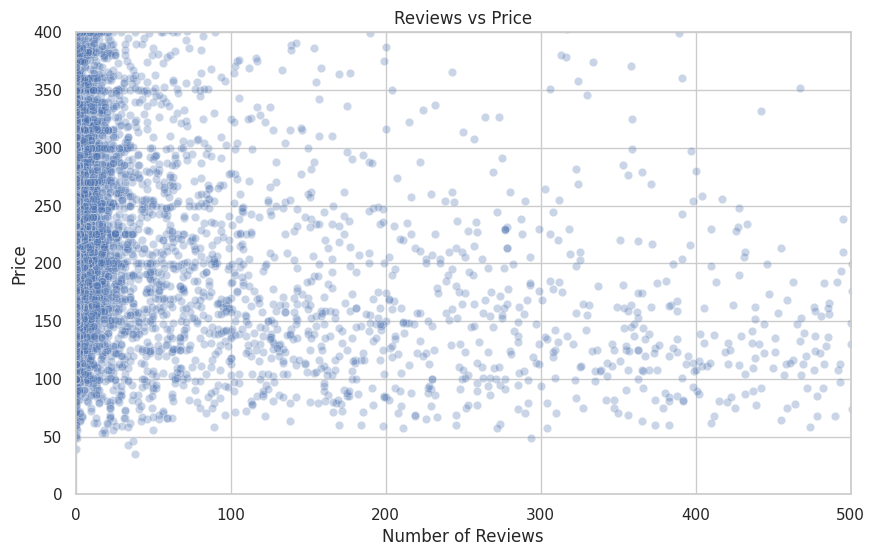

In [98]:
# Зависимость цены от количества отзывов
plt.figure(figsize=(10, 6))
sns.scatterplot(data=listings_clean, x="number_of_reviews", y="price", alpha=0.3)
plt.xlim(0, 500)
plt.ylim(0, 400)
plt.title("Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

Явной зависимости между количеством reviews и ценой жилья не наблюдается.

Listings с очень большим количеством reviews чаще относятся к среднему или низкому ценовому сегменту, тогда как дорогие объекты обычно имеют меньше reviews.

### Reviews vs Unavailability


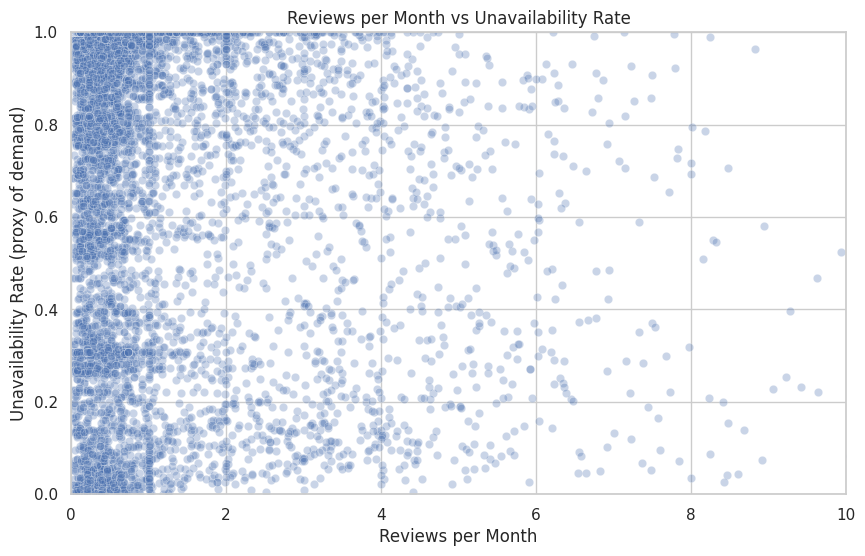

In [99]:
# Зависимость unavailability_rate от частоты отзывов
plt.figure(figsize=(10, 6))
sns.scatterplot(data=listings_clean, x="reviews_per_month", y="unavailability_rate", alpha=0.3)
plt.xlim(0, 10)
plt.ylim(0, 1)
plt.title("Reviews per Month vs Unavailability Rate")
plt.xlabel("Reviews per Month")
plt.ylabel("Unavailability Rate (proxy of demand)")
plt.show()


Listings с более высоким количеством reviews per month чаще имеют высокий unavailability rate.

Зависимость не сильная: высокий unavailability встречается как у highly active listings, так и у объектов с небольшим количеством reviews (что согласуется с регуляторными блокировками — высокая unavailability ≠ высокий спрос).


### Sentiment Proxy

In [100]:
# Review scores как прокси качества (НЕ sentiment — sentiment требует обработки текста)
rating_distribution = listings_clean["review_scores_rating"]
rating_distribution.describe()


count    9362.000000
mean        4.844551
std         0.256925
min         1.000000
25%         4.790000
50%         4.920000
75%         5.000000
max         5.000000
Name: review_scores_rating, dtype: float64

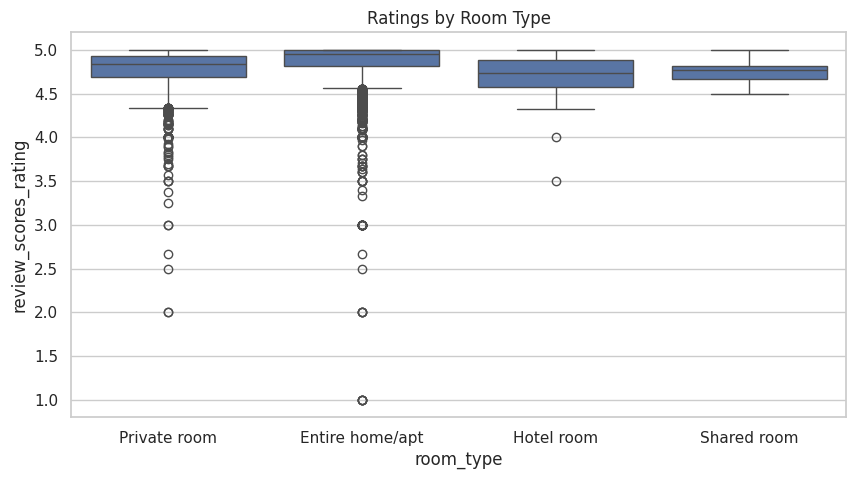

In [101]:
# Рейтинг по типу жилья
plt.figure(figsize=(10, 5))
sns.boxplot(data=listings_clean, x="room_type", y="review_scores_rating")
plt.title("Ratings by Room Type")
plt.show()

### Correlation & Feature Relationships

Корреляции между числовыми признаками: ищем сильные пары (для возможной удаления мультиколлинеарных фичей) и потенциальный leakage с `price`.


### Correlation Matrix

In [102]:
# Числовые признаки для корреляционного анализа
numerical_features = [
    "price", "log_price", "accommodates", "bedrooms", "beds",
    "availability_365", "unavailability_rate", "calendar_unavail_rate",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "distance_to_center", "host_listings_count", "revenue_proxy",
]


In [103]:
# Матрицы корреляций: Pearson для лога цены и Spearman для исходной цены
# (price имеет skew=31.55, поэтому Spearman/log_price корректнее)
corr_matrix_pearson  = listings_clean[numerical_features].corr(method="pearson")
corr_matrix_spearman = listings_clean[numerical_features].corr(method="spearman")
# Основная матрица для дальнейшей работы
corr_matrix = corr_matrix_spearman


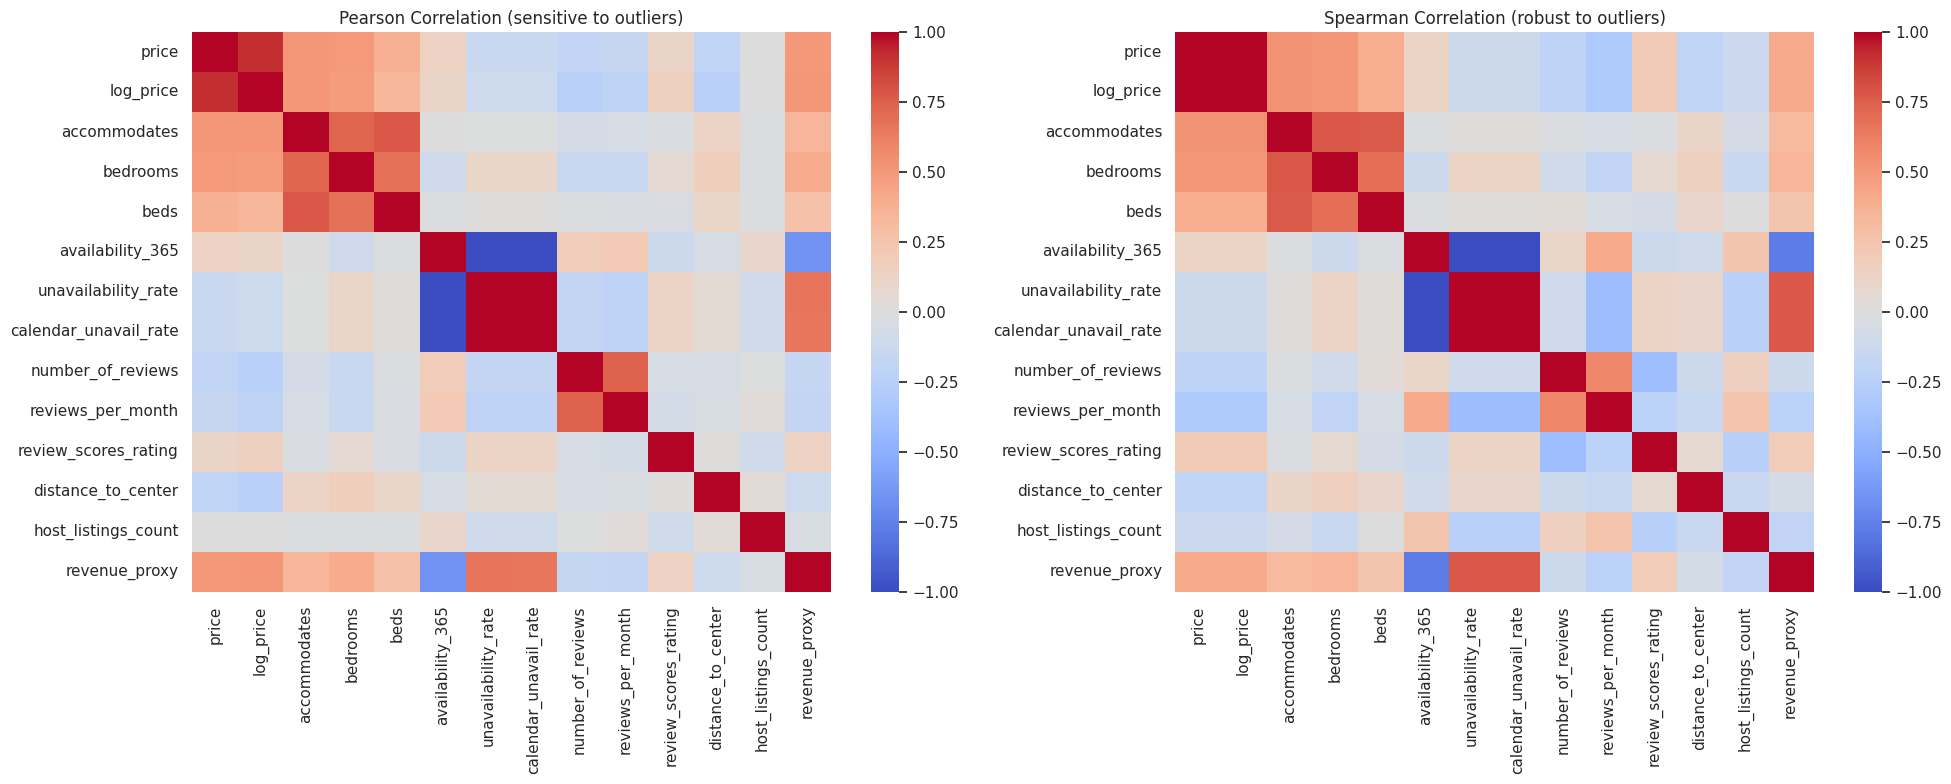

In [104]:
# Тепловые карты: Pearson vs Spearman
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(corr_matrix_pearson, cmap="coolwarm", center=0, annot=False, ax=axes[0])
axes[0].set_title("Pearson Correlation (sensitive to outliers)")
sns.heatmap(corr_matrix_spearman, cmap="coolwarm", center=0, annot=False, ax=axes[1])
axes[1].set_title("Spearman Correlation (robust to outliers)")
plt.tight_layout()
plt.show()


Spearman-корреляция (устойчива к выбросам) показывает:

**Сильные связи (|ρ| > 0.7):**
- `accommodates ↔ bedrooms ↔ beds` — характеристики жилья;
- `number_of_reviews ↔ reviews_per_month` — активность;
- `availability_365 ↔ unavailability_rate` — тавтология по определению;
- `price ↔ revenue_proxy` — тавтология (revenue = price × const).

**Умеренные связи с price:**
- `accommodates`, `bedrooms`, `beds` — положительная связь с ценой;
- `distance_to_center` — слабая отрицательная связь (премия за центр).

В целом большинство «корреляций» с price остаются умеренными — что подтверждает сложную нелинейную природу ценообразования и оправдывает использование gradient boosting вместо линейных моделей.


### Feature Relationships

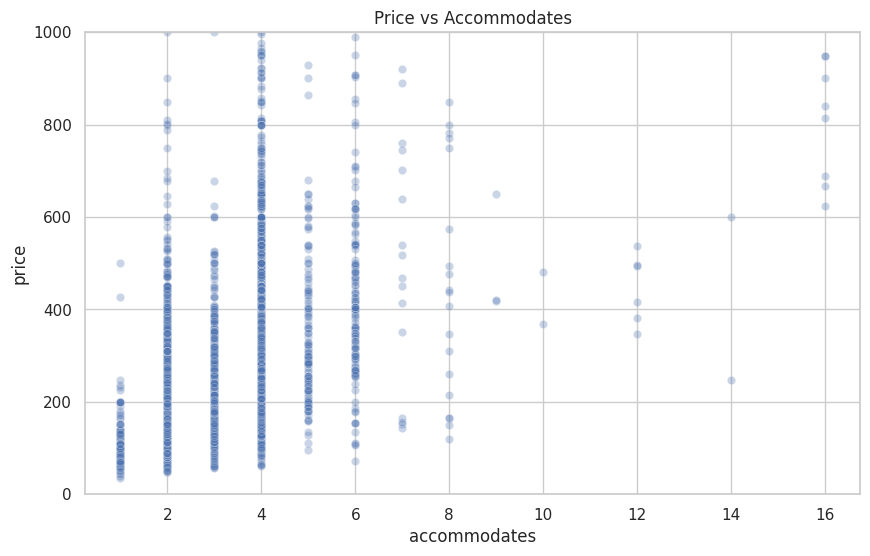

In [105]:
# Зависимость цены от вместимости
plt.figure(figsize=(10, 6))
sns.scatterplot(data=listings_clean, x="accommodates", y="price", alpha=0.3)
plt.ylim(0, 1000)
plt.title("Price vs Accommodates")
plt.show()

Наблюдается положительная связь между количеством гостей (`accommodates`) и ценой жилья: listings для большего числа гостей в среднем стоят дороже.

При этом внутри каждой группы сохраняется большой разброс цен, что указывает на влияние дополнительных факторов — локации, типа жилья, amenities и уровня качества.

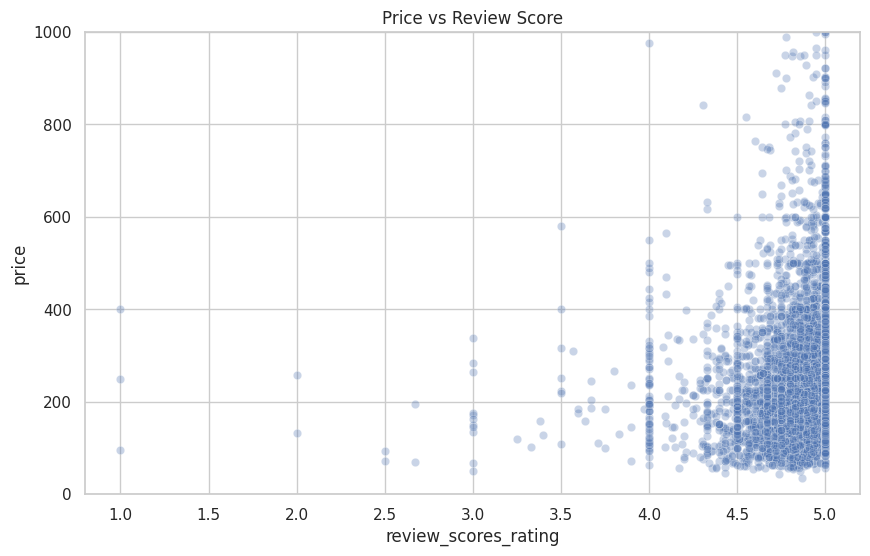

In [106]:
# Зависимость цены от рейтинга
plt.figure(figsize=(10, 6))
sns.scatterplot(data=listings_clean, x="review_scores_rating", y="price", alpha=0.3)
plt.ylim(0, 1000)
plt.title("Price vs Review Score")
plt.show()

Большинство listings имеют ratings выше 4.5 независимо от цены жилья.

Явной зависимости между review score и price не наблюдается: как дешевые, так и дорогие listings могут получать очень высокие оценки.

### Unavailability vs Availability


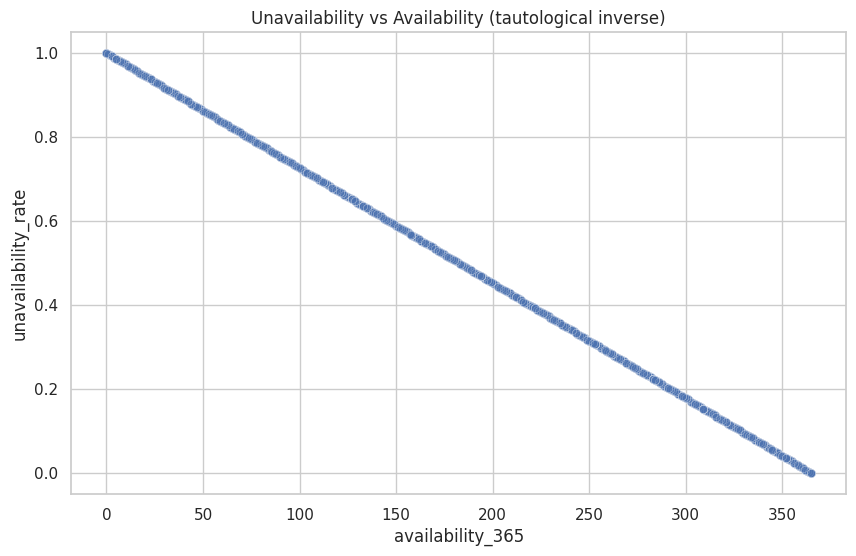

In [107]:
# Зависимость unavailability от доступности (по определению — идеальная отрицательная)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=listings_clean, x="availability_365", y="unavailability_rate", alpha=0.3)
plt.title("Unavailability vs Availability (tautological inverse)")
plt.show()


Наблюдается **идеальная** отрицательная связь между `availability_365` и `unavailability_rate` — это тавтология по определению (`unavailability_rate = (365 - availability_365) / 365`).

В ML-фичи нужно оставить **только одну** из этих переменных (или производную от calendar).


### Numerical Feature Analysis

In [108]:
# Описательная статистика числовых признаков
listings_clean[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
price,5844.0,257.280801,153.232913,35.000000,161.000000,221.000000,310.000000,1410.000000
log_price,5844.0,5.414756,0.519998,3.583519,5.087596,5.402677,5.739793,7.252054
accommodates,10448.0,2.915199,1.255403,1.000000,2.000000,2.000000,4.000000,16.000000
bedrooms,10142.0,1.550483,0.867953,0.000000,1.000000,1.000000,2.000000,10.000000
beds,5874.0,1.779537,1.508109,0.000000,1.000000,1.000000,2.000000,33.000000
availability_365,10448.0,93.639453,121.986486,0.000000,0.000000,20.000000,173.000000,365.000000
unavailability_rate,10448.0,0.743454,0.334210,0.000000,0.526027,0.945205,1.000000,1.000000
calendar_unavail_rate,10448.0,0.743309,0.334203,0.000000,0.526027,0.945205,1.000000,1.000000
number_of_reviews,10448.0,47.890123,131.673797,0.000000,3.000000,10.000000,30.000000,5097.000000
reviews_per_month,9362.0,0.999404,2.308420,0.010000,0.200000,0.410000,0.910000,99.420000


Числовые признаки показывают сильную вариативность Airbnb listings в Амстердаме.

Распределения `price`, `number_of_reviews`, `host_listings_count` и `estimated_revenue` имеют выраженные outliers и right-skewed форму, что указывает на наличие небольшого числа extremely active и high-value listings.

Также видно, что:
- медианный occupancy rate очень высокий (~0.95),
- большинство listings рассчитаны на 2–4 гостей,
- ratings в среднем остаются очень высокими (~4.84).

In [109]:
# Топ коррелирующих пар (без self-correlation = 1)
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs.head(15)


availability_365       calendar_unavail_rate    0.999367
calendar_unavail_rate  availability_365         0.999367
                       unavailability_rate      0.999367
unavailability_rate    calendar_unavail_rate    0.999367
accommodates           bedrooms                 0.776189
bedrooms               accommodates             0.776189
unavailability_rate    revenue_proxy            0.775912
availability_365       revenue_proxy            0.775912
revenue_proxy          availability_365         0.775912
                       unavailability_rate      0.775912
                       calendar_unavail_rate    0.775228
calendar_unavail_rate  revenue_proxy            0.775228
beds                   accommodates             0.766101
accommodates           beds                     0.766101
beds                   bedrooms                 0.689758
dtype: float64

Наиболее сильные пары (|ρ| > 0.7 по Spearman):

- `availability_365 ↔ unavailability_rate` — тавтология;
- `accommodates ↔ beds ↔ bedrooms` — характеристики вместимости;
- `price ↔ revenue_proxy` — тавтология (leakage для price-модели);
- `number_of_reviews ↔ reviews_per_month` — обе отражают активность.

Это указывает на multicollinearity и leakage-кандидатов. Для ML-модели нужно:
- удалить `revenue_proxy` и `unavailability_rate` (либо оставить только одну);
- из тройки `accommodates / beds / bedrooms` оставить наиболее информативную или применить PCA.


## EDA Key Findings

Exploratory Data Analysis охватил 10 480 listings, 22 района Амстердама, 3.8 M календарных записей и 501 K отзывов. Ниже — ключевые выводы с учётом обнаруженных ограничений данных.

### Качество данных и ограничения

- **43.95% listings без `price`** — для price-моделирования доступно ~5 874 объекта
- **Аномальные выбросы**: max price 80 018€/ночь, max `maximum_nights` 2.1 млрд — отфильтрованы на этапе cleaning.
- **calendar.price полностью пуст** в snapshot → невозможно построить динамику цен по дням, доступна только динамика availability.
- **`available` в calendar** = состояние слота, а не факт бронирования. Поэтому "occupancy" корректно называть `unavailability_rate` (верхняя граница спроса).

### Регуляторный контекст

В Амстердаме действует ограничение **30 ночей/год** для краткосрочной аренды без лицензии. Это критически меняет интерпретацию метрик доступности: низкое `availability_365` часто отражает не спрос, а юридический лимит. Поэтому unavailability ≠ occupancy.

### Ценообразование

- Распределение цен крайне правосмещённое (skewness=31.55 даже после фильтрации) → для ML используем `log_price`.
- **Медианная** цена корректнее средней: для Buitenveldert-Zuidas mean=3 013€ vs median=182€ — артефакт luxury / некорректных listings.
- Топ-районы по медианной цене: De Pijp - Rivierenbuurt (250€), Centrum-West (245.5€), De Baarsjes - Oud-West (240€), Centrum-Oost (240€), Zuid (238€).
- Самые доступные: Bijlmer-Oost (127.5€), Gaasperdam-Driemond (130.5€), Bijlmer-Centrum (134€).
- Room type — сильный ценовой фактор: Entire home/apt ≫ Private room ≫ Shared room.

### Пространственная структура

- Концентрация в центре: De Baarsjes - Oud-West (1 808 listings), Centrum-West (1 207), De Pijp (1 199) формируют ядро рынка.
- Price premium падает с расстоянием от центра в диапазоне 1–4 км.
- KMeans на координатах даёт устойчивые 5 пространственных кластеров (elbow).

### Спрос (с поправкой на регуляцию)

- `unavailability_rate` (наша метрика вместо некорректного "occupancy"): медиана 0.95 — артефакт регуляторных блокировок, не сплошной загрузки.
- Calendar-based unavailability совпадает с агрегатной метрикой → даёт per-day гранулярность для feature engineering.
- Сезонность из calendar: **минимум availability в сентябре** → пик туристического сезона. Это валидный сигнал спроса.
- Weekend vs weekday: разница < 1% — стабильный будничный спрос.

### Хосты

- ~10% listings принадлежат professional hosts (≥3 объектов); среди них коммерческие операторы (Limehome, Aishat, RoomPicks).
- **Superhosts имеют более низкую** медианную цену (188€ vs 230€) — гипотеза: лучшая цена → больше брони → быстрее набор отзывов → superhost статус. Требует проверки.
- Опыт хостов: медиана ~10 лет, среднее ~10 → рынок зрелый.

### Отзывы и рейтинги

- Сильное смещение ratings вверх: median 4.92. Слабый предиктор цены, потенциально полезен для conversion.
- 75% listings имеют < 30 отзывов — для надёжного NLP-анализа нужны топ-объекты или агрегации.
- Текстовые отзывы (501 K) **ещё не обработаны** — следующий шаг (TF-IDF / embeddings / sentiment).

### Multicollinearity и leakage

Сильные связи (Spearman |ρ| > 0.7), требующие очистки перед ML:
- `accommodates ↔ beds (0.79)`, `accommodates ↔ bedrooms (0.73)`;
- `number_of_reviews ↔ reviews_per_month (0.74)`;
- `availability_365 ↔ unavailability_rate (−1.0)` — тавтология;
- `price ↔ revenue_proxy (0.78)` — leakage для price-модели.
